# ✈️ NASA C-MAPSS FD004 — EDA + 전처리 + Feature Engineering

**[FD004 = 가장 어려운 데이터셋]** 6가지 운전 조건 + HPC + Fan 이중 고장 모드

| 항목 | FD002 | FD004 |
|------|-------|-------|
| 운전 조건 | 6가지 | **6가지** (동일) |
| 고장 모드 | HPC 열화 | **HPC + Fan 열화** |
| 클러스터링 | KMeans k=6 | **KMeans k=6** (동일) |
| 정규화 | 클러스터별 MinMax | **클러스터별 MinMax** |

공통 파이프라인: 수동 센서 제거 → 운전 조건 클러스터링(k=6) → **전처리 전 EDA** → RUL cap → 클러스터별 Gaussian → Validation 분리 → 클러스터별 MinMax + OHE → ML/DL 분기 → **전처리 후 검증** → CSV 저장

## 0. 환경 설정

In [1]:
import sys, subprocess
_NEEDED = ['numpy','pandas','scikit-learn','scipy','matplotlib','seaborn','statsmodels']
_miss = []
for pkg in _NEEDED:
    try:
        import importlib; importlib.import_module('sklearn' if pkg=='scikit-learn' else pkg)
    except ImportError:
        _miss.append(pkg)
if _miss:
    subprocess.check_call([sys.executable,'-m','pip','install','-q',*_miss])
print(f'✅ 라이브러리 준비 완료')

✅ 라이브러리 준비 완료


In [2]:
import os, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import platform
import joblib
from scipy.ndimage import gaussian_filter1d
from scipy.stats import (ks_2samp, kruskal, kendalltau, ttest_rel,
                          shapiro, wilcoxon, spearmanr)
from statsmodels.stats.multitest import multipletests
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D
warnings.filterwarnings('ignore')

import logging
import matplotlib.font_manager as fm
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

def force_korean_font():
    system = platform.system()
    if system == "Windows":
        font_path = "C:/Windows/Fonts/malgun.ttf"; font_name = "Malgun Gothic"
    elif system == "Darwin":
        font_path = "/System/Library/Fonts/AppleGothic.ttf"; font_name = "AppleGothic"
    else:
        font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"; font_name = "NanumGothic"
        if not os.path.exists(font_path):
            os.system("apt-get update -qq"); os.system("apt-get install -y fonts-nanum -qq")
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rcParams["font.family"] = font_name
        plt.rcParams["font.sans-serif"] = [font_name]
        plt.rcParams["axes.unicode_minus"] = False
        print(f"✅ 한글 폰트 적용: {font_name}")
    else:
        print("❌ 폰트 못 찾음")

force_korean_font()

BG, BG2, GRID = '#0f1117', '#1a1d2e', '#2d3148'
WHITE, GRAY   = '#ffffff', '#aaaaaa'
C = ['#00d4ff','#ff6b6b','#51cf66','#ffd43b','#a29bfe','#fd79a8','#00b894','#e17055']
CLUSTER_COLORS = ['#00d4ff','#ff6b6b','#51cf66','#ffd43b','#a29bfe','#fd79a8']
plt.rcParams.update({
    'figure.facecolor': BG,  'axes.facecolor': BG2, 'axes.edgecolor': GRID,
    'axes.labelcolor': GRAY, 'xtick.color': GRAY,   'ytick.color': GRAY,
    'text.color': WHITE,     'grid.color': GRID,     'grid.alpha': 0.4,
    'axes.grid': True,       'font.size': 10,        'axes.titlesize': 11,
    'legend.facecolor': BG2, 'legend.edgecolor': GRID,
})
force_korean_font()

cmap_rg = LinearSegmentedColormap.from_list('rg', ['#ff6b6b','#1a1d2e','#00d4ff'], N=256)

RAW_COLS = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1, 22)]
RENAME_MAP = {
    'unit':'unit_nr', 'cycle':'time_cycles',
    'op1':'setting_1','op2':'setting_2','op3':'setting_3',
    **{f's{i}': f's_{i}' for i in range(1, 22)}
}
SENSOR_COLS  = [f's_{i}' for i in range(1, 22)]
OP_COLS      = ['setting_1','setting_2','setting_3']
ID_COLS      = ['unit_nr','time_cycles']
RUL_CAP      = 125
GAUSS_SIGMA  = 2
CONST_THR    = 0.01
N_CLUSTERS   = 6

TEMPORAL_LAGS      = [1, 3, 5]
TEMPORAL_DIFFS     = [1]
TEMPORAL_ROLLS     = [3, 5]
TEMPORAL_ROLL_STDS = [3, 5]
TEMPORAL_EMAS      = [5]
WINDOW_SIZE = 30
STEP = 1

SENSOR_DESC = {
    's_1':'T2 팬 입구 온도(°R)',      's_2':'T24 LPC 출구 온도(°R)',
    's_3':'T30 HPC 출구 온도(°R)',    's_4':'T50 LPT 출구 온도(°R)',
    's_5':'P2 팬 입구 압력(psia)',     's_6':'P15 바이패스 압력(psia)',
    's_7':'P30 HPC 출구 압력(psia)',  's_8':'Nf 팬 속도(rpm)',
    's_9':'Nc 코어 속도(rpm)',         's_10':'epr 엔진 압력비',
    's_11':'Ps30 정적압력(psia)',      's_12':'phi 연료/Ps30 비율',
    's_13':'NRf 보정 팬 속도(rpm)',    's_14':'NRc 보정 코어속도(rpm)',
    's_15':'BPR 바이패스 비율',        's_16':'farB 버너 연료공기비',
    's_17':'htBleed 블리드 엔탈피',    's_18':'Nf_dmd 요구 팬 속도',
    's_19':'PCNfR 요구 보정 팬속도',   's_20':'W31 HPT 냉각블리드',
    's_21':'W32 LPT 냉각블리드',
}

# FD004 전용: Fan vs HPC 관련 센서 분류
FAN_SENSORS = ['s_1','s_6','s_8','s_13','s_15']
HPC_SENSORS = ['s_3','s_7','s_9','s_11','s_12']

print('✅ 환경 설정 완료')
print(f'   데이터셋: FD004 (6가지 조건, HPC+Fan 이중 고장 — 최고 난이도)')
print(f'   N_CLUSTERS={N_CLUSTERS}  RUL_CAP={RUL_CAP}  σ={GAUSS_SIGMA}')

✅ 한글 폰트 적용: Malgun Gothic
✅ 한글 폰트 적용: Malgun Gothic
✅ 환경 설정 완료
   데이터셋: FD004 (6가지 조건, HPC+Fan 이중 고장 — 최고 난이도)
   N_CLUSTERS=6  RUL_CAP=125  σ=2


## 1. 데이터 로딩 & 컬럼명 표준화

In [3]:
DATA_DIR = 'CMAPSSData'
for c in ['CMAPSSData','./CMAPSSData','../CMAPSSData','../../CMAPSSData',
    '../../../CMAPSSData',
    '../../../../CMAPSSData']:
    if os.path.exists(os.path.join(c,'train_FD004.txt')):
        DATA_DIR = c; break
else:
    print(f'❌ 경로 없음: {os.getcwd()}')

kw = dict(sep=r'\s+', header=None, names=RAW_COLS, engine='python')
train_raw = pd.read_csv(f'{DATA_DIR}/train_FD004.txt', **kw)
test_raw  = pd.read_csv(f'{DATA_DIR}/test_FD004.txt',  **kw)
rul_df    = pd.read_csv(f'{DATA_DIR}/RUL_FD004.txt',
                        sep=r'\s+', header=None, names=['RUL'], engine='python')
train_raw.rename(columns=RENAME_MAP, inplace=True)
test_raw.rename( columns=RENAME_MAP, inplace=True)

print('✅ FD004 로딩 완료')
print(f'   Train : {train_raw.shape}  |  엔진 {train_raw["unit_nr"].nunique()}대')
print(f'   Test  : {test_raw.shape}   |  엔진 {test_raw["unit_nr"].nunique()}대')
print(f'   RUL   : {rul_df.shape}')
display(train_raw.head(3))

✅ FD004 로딩 완료
   Train : (61249, 26)  |  엔진 249대
   Test  : (41214, 26)   |  엔진 248대
   RUL   : (248, 1)


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.0,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.0,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.0,10.48,6.4213


## 2. 수동 센서 제거 (FD004 기준)

**FD004 수동 제거 근거 (FD002/003 EDA 결과 참조):**
- `s_1, s_5, s_18, s_19` → std ≈ 0, 완전 상수 (FD001/002/003 공통 제거)
- `s_6` → FD004에서도 변동 미미, Fan 고장 영향이 다른 센서에 더 명확히 반영됨
- FD002 대비 `s_16` **유지** → Fan 열화 시 farB(버너 연료공기비) 변화 가능성

=== 2. FD004 수동 센서 선택 ===
수동 제거 (6개): ['s_1', 's_5', 's_6', 's_16', 's_18', 's_19']
수동 유지 (15개): ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
✅ 최종 통일 센서 기준 검증 완료: 6개 제거 → 15개 유지


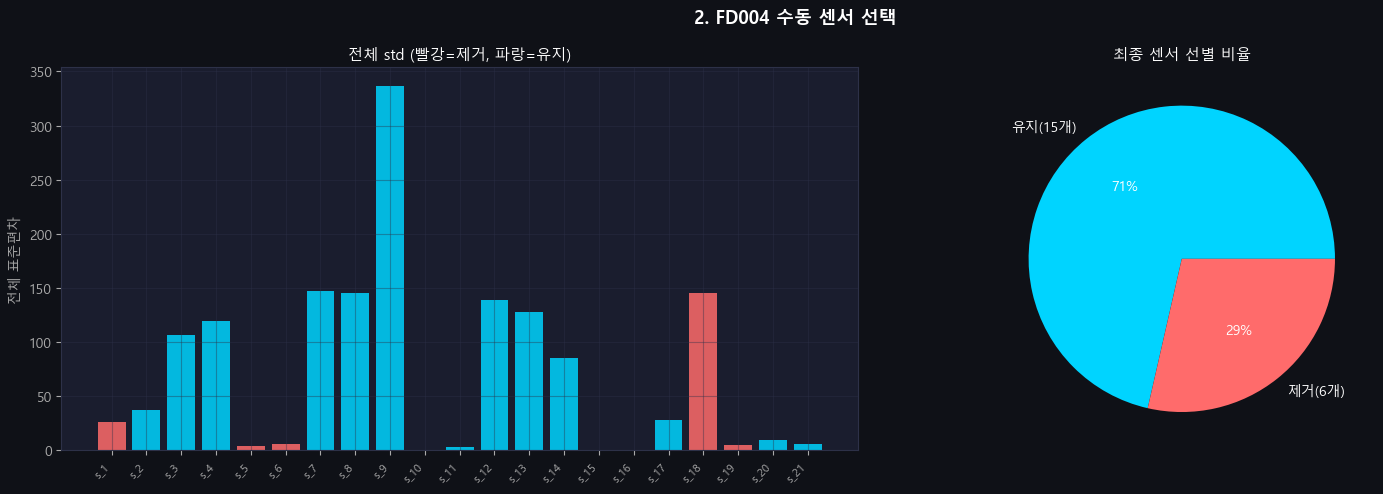


[FD002 vs FD004 유효 센서 비교]
  FD004에만 추가: ['s_10']  (최종 기준에서는 s_10만 추가, s_16은 제거)
  FD002에만 있음: []


In [4]:
print('=== 2. FD004 수동 센서 선택 ===')
FINAL_REMOVE_SENSORS = ['s_1', 's_5', 's_6', 's_16', 's_18', 's_19']
FINAL_USEFUL_SENSORS = ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_10',
                        's_11', 's_12', 's_13', 's_14', 's_15',
                        's_17', 's_20', 's_21']
MANUAL_REMOVE = FINAL_REMOVE_SENSORS.copy()
REMOVE_SENSORS = sorted(MANUAL_REMOVE, key=lambda x: int(x.split('_')[1]))
USEFUL_SENSORS = sorted([s for s in SENSOR_COLS if s not in REMOVE_SENSORS],
                        key=lambda x: int(x.split('_')[1]))

print(f'수동 제거 ({len(REMOVE_SENSORS)}개): {REMOVE_SENSORS}')
print(f'수동 유지 ({len(USEFUL_SENSORS)}개): {USEFUL_SENSORS}')

# 최종 통일 센서 기준 검증
assert REMOVE_SENSORS == FINAL_REMOVE_SENSORS, f'제거 센서 불일치: {REMOVE_SENSORS}'
assert USEFUL_SENSORS == FINAL_USEFUL_SENSORS, f'유지 센서 불일치: {USEFUL_SENSORS}'
assert len(USEFUL_SENSORS) == 15, f'유지 센서 수가 15개가 아닙니다: {len(USEFUL_SENSORS)}'
print('✅ 최종 통일 센서 기준 검증 완료: 6개 제거 → 15개 유지')

KEEP = ID_COLS + OP_COLS + USEFUL_SENSORS
train_s1 = train_raw[KEEP].copy()
test_s1  = test_raw[KEEP].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('2. FD004 수동 센서 선택', fontsize=13, fontweight='bold')

train_std = train_raw[SENSOR_COLS].std()
colors = ['#ff6b6b' if s in REMOVE_SENSORS else '#00d4ff' for s in SENSOR_COLS]
axes[0].bar(range(len(SENSOR_COLS)), train_std.values, color=colors, alpha=0.85)
axes[0].set_xticks(range(len(SENSOR_COLS)))
axes[0].set_xticklabels(SENSOR_COLS, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('전체 표준편차')
axes[0].set_title('전체 std (빨강=제거, 파랑=유지)')

axes[1].pie([len(USEFUL_SENSORS), len(REMOVE_SENSORS)],
            labels=[f'유지({len(USEFUL_SENSORS)}개)', f'제거({len(REMOVE_SENSORS)}개)'],
            colors=[C[0], C[1]], autopct='%1.0f%%', textprops={'color': WHITE})
axes[1].set_title('최종 센서 선별 비율')
plt.tight_layout(); plt.show()

print('\n[FD002 vs FD004 유효 센서 비교]')
fd002_useful = ['s_2','s_3','s_4','s_7','s_8','s_9','s_11','s_12','s_13','s_14','s_15','s_17','s_20','s_21']
fd004_only = [s for s in USEFUL_SENSORS if s not in fd002_useful]
fd002_only = [s for s in fd002_useful if s not in USEFUL_SENSORS]
print(f'  FD004에만 추가: {fd004_only}  (최종 기준에서는 s_10만 추가, s_16은 제거)')
print(f'  FD002에만 있음: {fd002_only}')

## 3. [FD004 핵심] 운전 조건 클러스터링 (KMeans k=6)

FD004는 6가지 운전 조건(Altitude, Mach, TRA 조합)이 혼재. EDA 전에 클러스터링을 수행하여
이후 모든 분석을 클러스터 단위로 진행함 (FD002 동일 전략).

### 3-1. 최적 클러스터 수 탐색 (Elbow + Silhouette)

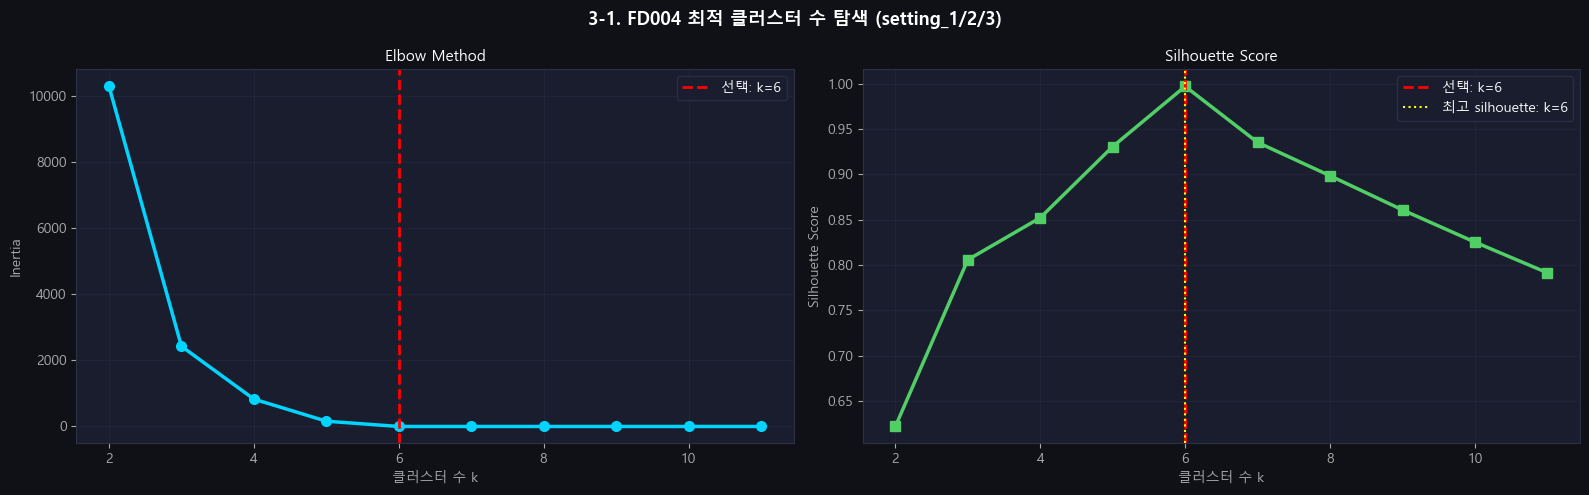

선택: k=6  |  Silhouette=0.9970
최고 Silhouette: k=6  |  score=0.9970


In [5]:
op_data = MinMaxScaler().fit_transform(train_s1[OP_COLS])
inertias, silhouettes = [], []
K_range = range(2, 12)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300)
    labels = km.fit_predict(op_data)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(op_data, labels))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('3-1. FD004 최적 클러스터 수 탐색 (setting_1/2/3)', fontsize=13, fontweight='bold')
axes[0].plot(list(K_range), inertias, color=C[0], lw=2.5, marker='o', markersize=7)
axes[0].axvline(N_CLUSTERS, color='red', ls='--', lw=2, label=f'선택: k={N_CLUSTERS}')
axes[0].set_xlabel('클러스터 수 k'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method'); axes[0].legend()
axes[1].plot(list(K_range), silhouettes, color=C[2], lw=2.5, marker='s', markersize=7)
best_k = list(K_range)[np.argmax(silhouettes)]
axes[1].axvline(N_CLUSTERS, color='red', ls='--', lw=2, label=f'선택: k={N_CLUSTERS}')
axes[1].axvline(best_k, color='yellow', ls=':', lw=1.5, label=f'최고 silhouette: k={best_k}')
axes[1].set_xlabel('클러스터 수 k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score'); axes[1].legend()
plt.tight_layout(); plt.show()
print(f'선택: k={N_CLUSTERS}  |  Silhouette={silhouettes[N_CLUSTERS-2]:.4f}')
print(f'최고 Silhouette: k={best_k}  |  score={max(silhouettes):.4f}')

### 3-2. KMeans 클러스터링 수행 & 조건 분포 확인

=== 클러스터별 운전 조건 프로파일 ===


,setting_1,setting_2,setting_3,row_count,비율(%)
op_cluster,,,,,
0,42.0030,0.8405,100.0,15395,25.14
1,10.0030,0.2505,100.0,9224,15.06
2,25.0031,0.6205,60.0,9139,14.92
3,20.0030,0.7005,100.0,9091,14.84
4,0.0015,0.0005,100.0,9238,15.08
5,35.0030,0.8405,100.0,9162,14.96


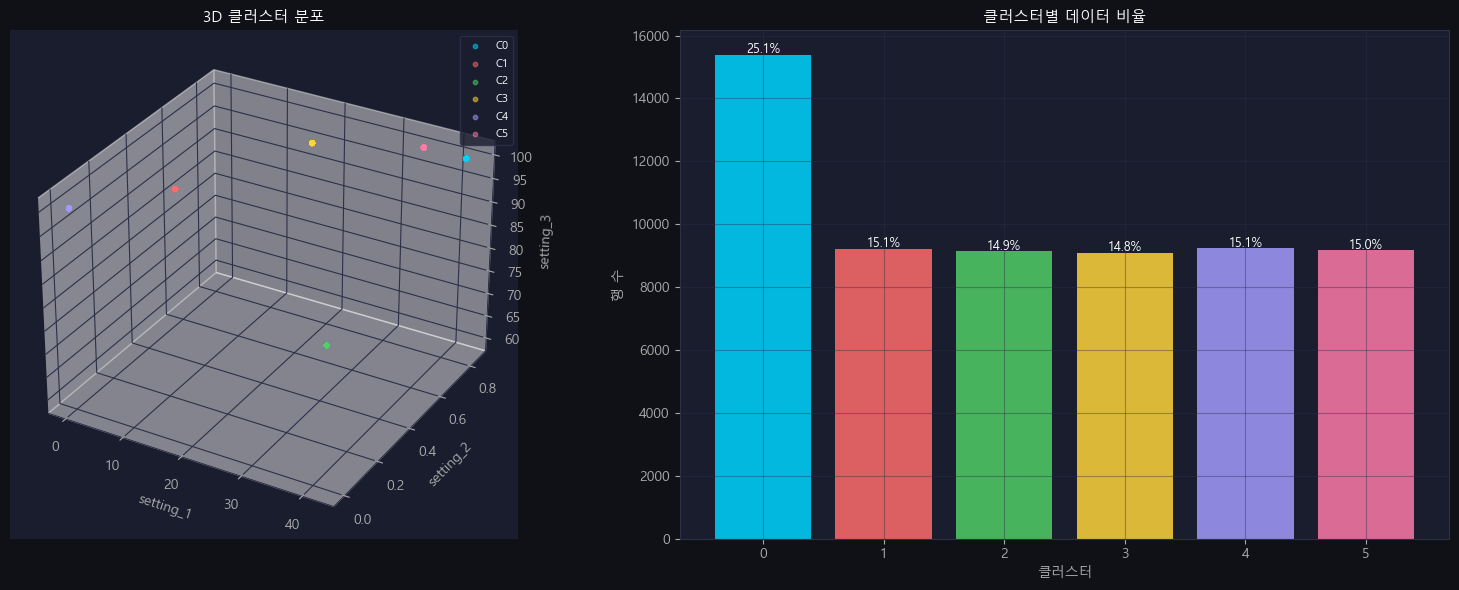

In [6]:
op_scaler = MinMaxScaler()
op_train_z = op_scaler.fit_transform(train_s1[OP_COLS])
op_test_z  = op_scaler.transform(test_s1[OP_COLS])

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20, max_iter=300)
kmeans.fit(op_train_z)

train_s1['op_cluster'] = kmeans.labels_
test_s1['op_cluster']  = kmeans.predict(op_test_z)
train_raw['op_cluster'] = train_s1['op_cluster'].values
test_raw['op_cluster']  = test_s1['op_cluster'].values

joblib.dump(op_scaler, 'FD004_op_scaler.pkl')

cluster_profile = (train_raw.groupby('op_cluster')[OP_COLS + ['unit_nr']]
                   .agg({'setting_1':'mean','setting_2':'mean','setting_3':'mean','unit_nr':'count'})
                   .rename(columns={'unit_nr':'row_count'}))
cluster_profile['비율(%)'] = (cluster_profile['row_count']/len(train_raw)*100).round(2)
print('=== 클러스터별 운전 조건 프로파일 ===')
display(cluster_profile.round(4))

# 3D 산점도
fig = plt.figure(figsize=(16, 6))
ax1 = fig.add_subplot(121, projection='3d')
sample_idx = np.random.choice(len(train_s1), min(3000, len(train_s1)), replace=False)
smp = train_s1.iloc[sample_idx]
for c in range(N_CLUSTERS):
    mask = smp['op_cluster'] == c
    ax1.scatter(smp.loc[mask,'setting_1'], smp.loc[mask,'setting_2'],
                smp.loc[mask,'setting_3'], color=CLUSTER_COLORS[c],
                s=10, alpha=0.5, label=f'C{c}')
ax1.set_xlabel('setting_1'); ax1.set_ylabel('setting_2'); ax1.set_zlabel('setting_3')
ax1.set_title('3D 클러스터 분포'); ax1.legend(fontsize=8)

ax2 = fig.add_subplot(122)
cnts = train_s1['op_cluster'].value_counts().sort_index()
ax2.bar(cnts.index, cnts.values, color=CLUSTER_COLORS, alpha=0.85)
ax2.set_xlabel('클러스터'); ax2.set_ylabel('행 수')
ax2.set_title('클러스터별 데이터 비율')
for i, v in zip(cnts.index, cnts.values):
    ax2.text(i, v+50, f'{v/len(train_s1)*100:.1f}%', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

### 3-3. 클러스터 일관성 검증 & Train/Test 비율 비교

--- 엔진별 운전 조건 다양성 ---
count    249.0
mean       6.0
std        0.0
min        6.0
25%        6.0
50%        6.0
75%        6.0
max        6.0
dtype: float64


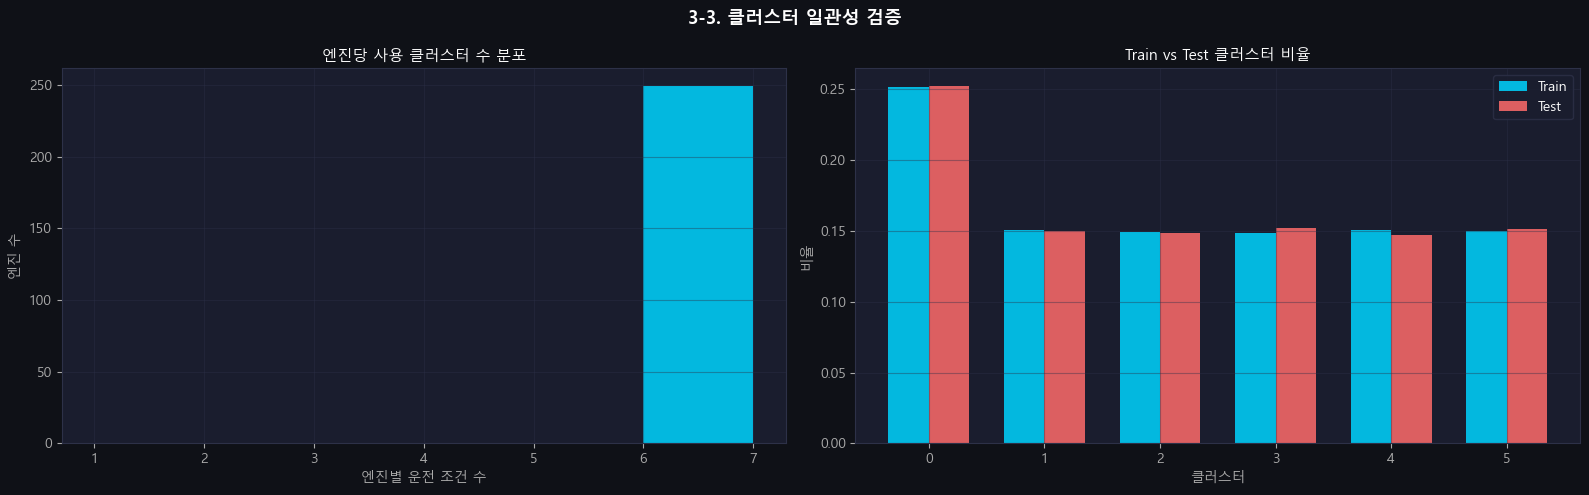


Chi-square 검정: chi2=5.05  df=5  p=0.4096
판정: ✅ Train/Test 클러스터 비율 동질


In [7]:
# 엔진별 클러스터 다양성
engine_cluster_cnt = (train_raw.groupby(['unit_nr','op_cluster']).size()
                      .reset_index().groupby('unit_nr').size())
print('--- 엔진별 운전 조건 다양성 ---')
print(engine_cluster_cnt.describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('3-3. 클러스터 일관성 검증', fontsize=13, fontweight='bold')
axes[0].hist(engine_cluster_cnt, bins=range(1, N_CLUSTERS+2), color=C[0], alpha=0.85, edgecolor='none')
axes[0].set_xlabel('엔진별 운전 조건 수'); axes[0].set_ylabel('엔진 수')
axes[0].set_title('엔진당 사용 클러스터 수 분포')

tr_pct = train_raw['op_cluster'].value_counts(normalize=True).sort_index()
te_pct = test_raw['op_cluster'].value_counts(normalize=True).sort_index()
x = np.arange(N_CLUSTERS); w = 0.35
axes[1].bar(x-w/2, tr_pct.values, w, color=C[0], alpha=0.85, label='Train')
axes[1].bar(x+w/2, te_pct.reindex(range(N_CLUSTERS), fill_value=0).values,
            w, color=C[1], alpha=0.85, label='Test')
axes[1].set_xlabel('클러스터'); axes[1].set_ylabel('비율')
axes[1].set_title('Train vs Test 클러스터 비율'); axes[1].legend()
plt.tight_layout(); plt.show()

# Chi-square 검정
from scipy.stats import chi2_contingency
tr_cnt = train_raw['op_cluster'].value_counts().sort_index()
te_cnt = test_raw['op_cluster'].value_counts().sort_index()
ct = pd.DataFrame({'Train': tr_cnt, 'Test': te_cnt}).fillna(0).T
chi2, p_chi2, dof, _ = chi2_contingency(ct)
print(f'\nChi-square 검정: chi2={chi2:.2f}  df={dof}  p={p_chi2:.4f}')
print('판정:', '✅ Train/Test 클러스터 비율 동질' if p_chi2>0.05 else '⚠️ 비율 차이 유의')

### 3-EXTRA-A. 클러스터 전이 행렬 & 거주 시간

=== 3-EXTRA-A. 클러스터 전이 / 거주 시간 ===


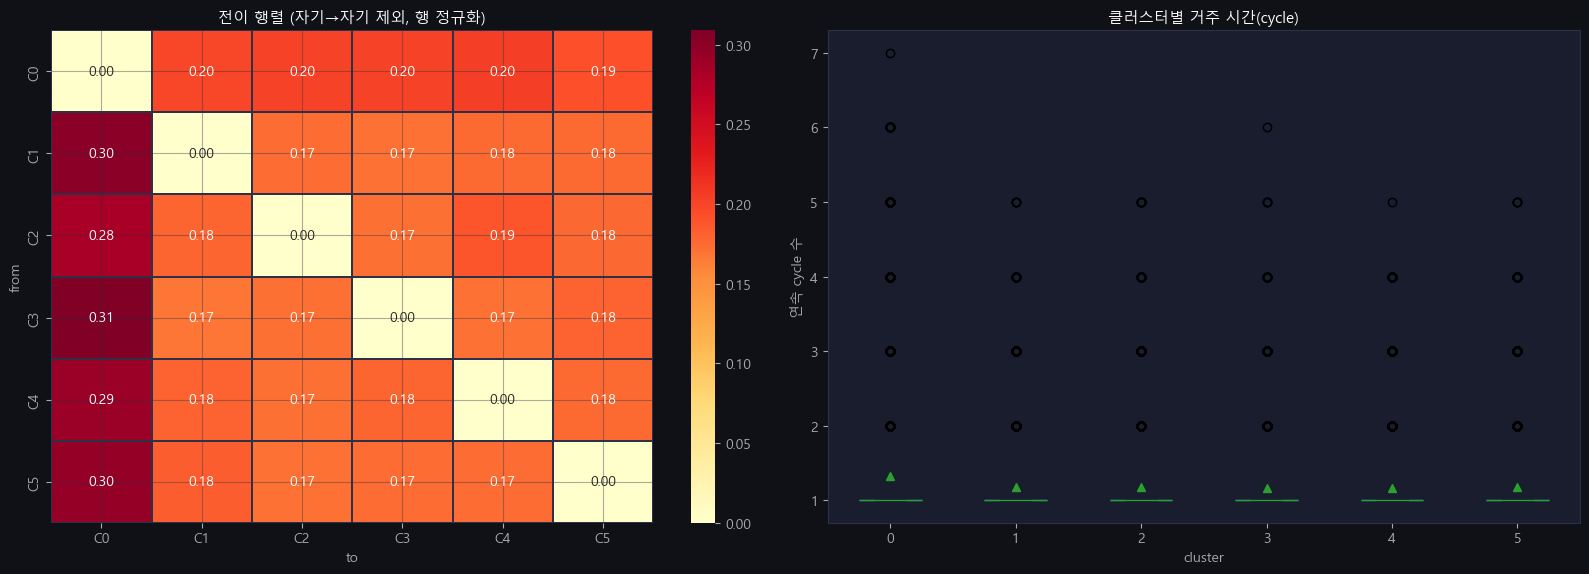


클러스터별 평균 거주 시간:
         mean  median  max
cluster                   
0         1.3     1.0    7
1         1.2     1.0    5
2         1.2     1.0    5
3         1.2     1.0    6
4         1.2     1.0    5
5         1.2     1.0    5


In [8]:
print('=== 3-EXTRA-A. 클러스터 전이 / 거주 시간 ===')

trans = np.zeros((N_CLUSTERS, N_CLUSTERS), dtype=int)
dwell_times = []
for uid in train_raw['unit_nr'].unique():
    seq = train_raw[train_raw['unit_nr']==uid].sort_values('time_cycles')['op_cluster'].values
    for a, b in zip(seq[:-1], seq[1:]):
        trans[a, b] += 1
    rl = 1
    for k in range(1, len(seq)):
        if seq[k] == seq[k-1]:
            rl += 1
        else:
            dwell_times.append((seq[k-1], rl)); rl = 1
    dwell_times.append((seq[-1], rl))

dwell_df = pd.DataFrame(dwell_times, columns=['cluster','cycles'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('3-EXTRA-A. 클러스터 전이 행렬 & 거주 시간 [FD004]', fontsize=13, fontweight='bold')

trans_off = trans.copy().astype(float)
np.fill_diagonal(trans_off, 0)
trans_norm = trans_off / np.maximum(trans_off.sum(axis=1, keepdims=True), 1)
sns.heatmap(trans_norm, ax=axes[0], cmap='YlOrRd', annot=True, fmt='.2f',
            xticklabels=[f'C{i}' for i in range(N_CLUSTERS)],
            yticklabels=[f'C{i}' for i in range(N_CLUSTERS)],
            linewidths=0.3, linecolor=GRID)
axes[0].set_title('전이 행렬 (자기→자기 제외, 행 정규화)')
axes[0].set_xlabel('to'); axes[0].set_ylabel('from')

dwell_df.boxplot(column='cycles', by='cluster', ax=axes[1], grid=False,
                 patch_artist=True, showmeans=True)
axes[1].set_title('클러스터별 거주 시간(cycle)')
axes[1].set_xlabel('cluster'); axes[1].set_ylabel('연속 cycle 수')
plt.suptitle(''); plt.tight_layout(); plt.show()

print('\n클러스터별 평균 거주 시간:')
print(dwell_df.groupby('cluster')['cycles'].agg(['mean','median','max']).round(1))

### 3-EXTRA-B. 엔진별 cluster 비중 vs 수명 상관 (Spearman)

=== 3-EXTRA-B. 엔진별 cluster 비중 vs 수명 ===


,cluster,spearman_r,p-value,판정
0,C0,-0.025,0.6947,비유의 ⚠️
1,C1,0.184,0.0036,유의 ✅
2,C2,0.011,0.8643,비유의 ⚠️
3,C3,0.003,0.9583,비유의 ⚠️
4,C4,-0.116,0.0680,비유의 ⚠️
5,C5,-0.013,0.8385,비유의 ⚠️


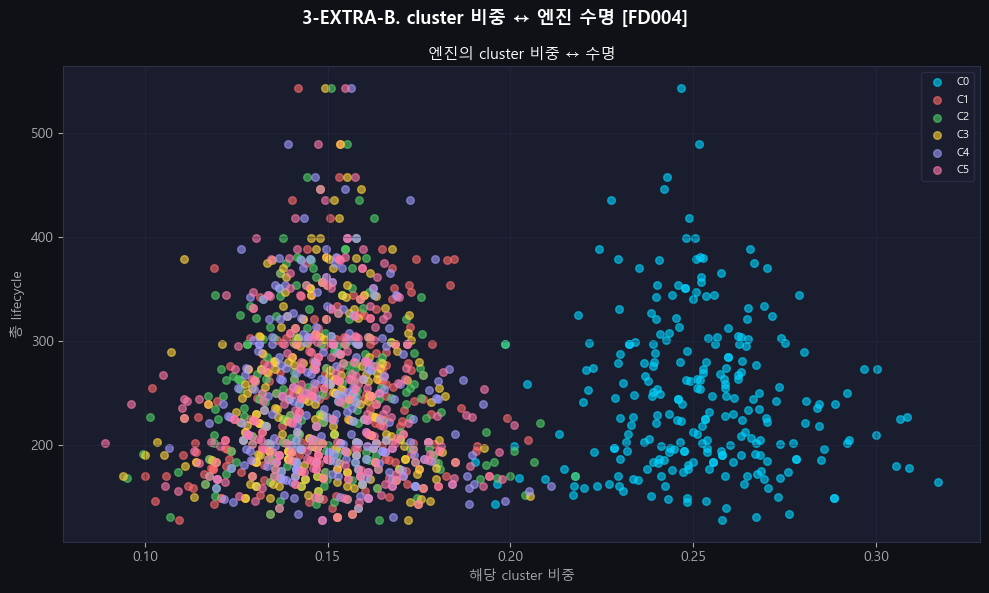

In [9]:
print('=== 3-EXTRA-B. 엔진별 cluster 비중 vs 수명 ===')

mc = train_raw.groupby('unit_nr')['time_cycles'].max().rename('lifecycle')
mix = (train_raw.groupby(['unit_nr','op_cluster']).size().unstack(fill_value=0))
mix = mix.div(mix.sum(axis=1), axis=0)
mix.columns = [f'C{c}_pct' for c in mix.columns]
mix = mix.join(mc)

rows = []
for c in range(N_CLUSTERS):
    col = f'C{c}_pct'
    if col not in mix.columns: continue
    r, p = spearmanr(mix[col], mix['lifecycle'])
    rows.append({'cluster': f'C{c}', 'spearman_r': round(r,3),
                 'p-value': round(p,4), '판정': '유의 ✅' if p<0.05 else '비유의 ⚠️'})
display(pd.DataFrame(rows))

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('3-EXTRA-B. cluster 비중 ↔ 엔진 수명 [FD004]', fontsize=13, fontweight='bold')
for c in range(N_CLUSTERS):
    col = f'C{c}_pct'
    if col not in mix.columns: continue
    ax.scatter(mix[col], mix['lifecycle'], color=CLUSTER_COLORS[c], alpha=0.6, s=30, label=f'C{c}')
ax.set_xlabel('해당 cluster 비중'); ax.set_ylabel('총 lifecycle')
ax.set_title('엔진의 cluster 비중 ↔ 수명'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 3-EXTRA-C. Sensor trajectory by RUL bin × Cluster

=== 3-EXTRA-C. Sensor trajectory by RUL bin × Cluster ===


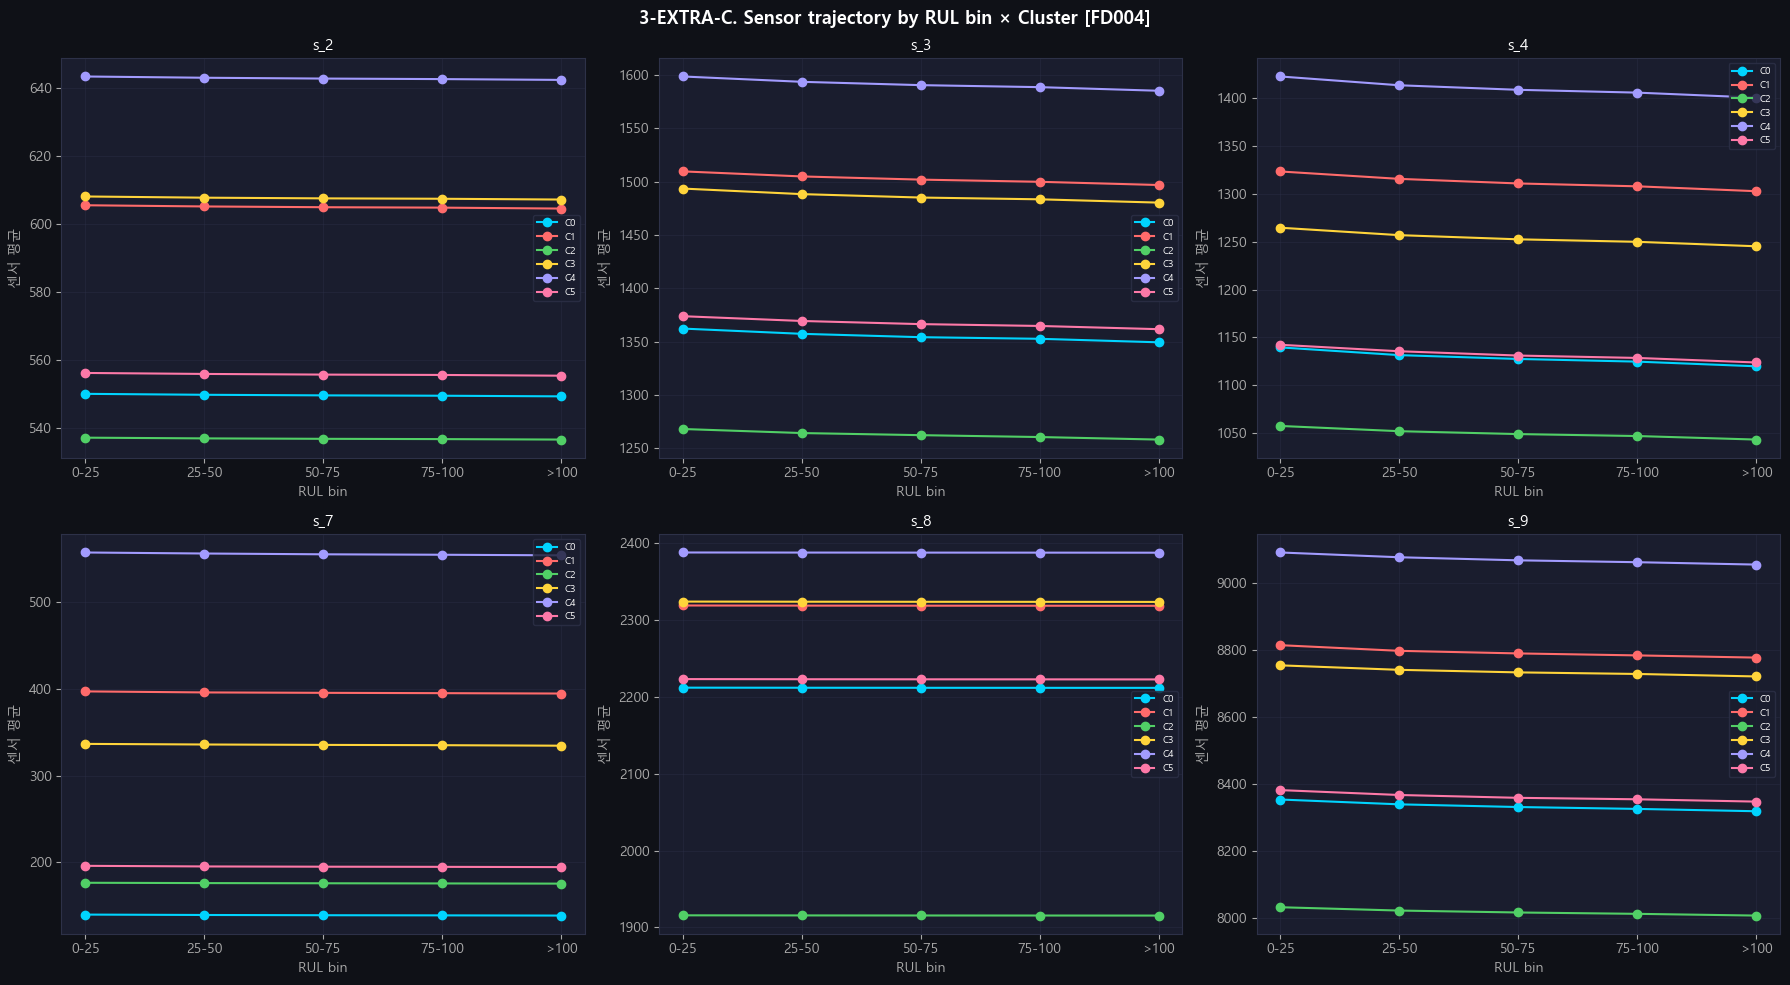

In [10]:
print('=== 3-EXTRA-C. Sensor trajectory by RUL bin × Cluster ===')

mc = train_raw.groupby('unit_nr')['time_cycles'].max().rename('max_c')
trj = train_raw.join(mc, on='unit_nr')
trj['RUL'] = trj['max_c'] - trj['time_cycles']
trj['rul_bin'] = pd.cut(trj['RUL'], bins=[-1,25,50,75,100,1e6],
                        labels=['0-25','25-50','50-75','75-100','>100'])

top6 = USEFUL_SENSORS[:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('3-EXTRA-C. Sensor trajectory by RUL bin × Cluster [FD004]',
             fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, top6):
    for c in range(N_CLUSTERS):
        sub = trj[trj['op_cluster']==c]
        means = sub.groupby('rul_bin', observed=True)[s].mean()
        ax.plot(means.index.astype(str), means.values,
                color=CLUSTER_COLORS[c], marker='o', lw=1.5, label=f'C{c}')
    ax.set_title(s); ax.set_xlabel('RUL bin'); ax.set_ylabel('센서 평균')
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

### 3-EXTRA-D. 분산 분해 — Engine vs Cluster vs Cycle

=== 3-EXTRA-D. 분산 분해 ===


,engine_pct,cluster_pct,within_pct
센서,,,
s_1,0.200000,116.400000,0.000000
s_2,0.300000,123.600000,0.000000
s_3,0.300000,127.200000,0.000000
s_4,0.400000,126.200000,0.000000
s_5,0.200000,113.600000,0.000000
s_6,0.200000,115.500000,0.000000
s_7,0.300000,118.500000,0.000000
s_8,0.300000,133.600000,0.000000
s_9,0.300000,127.900000,0.000000


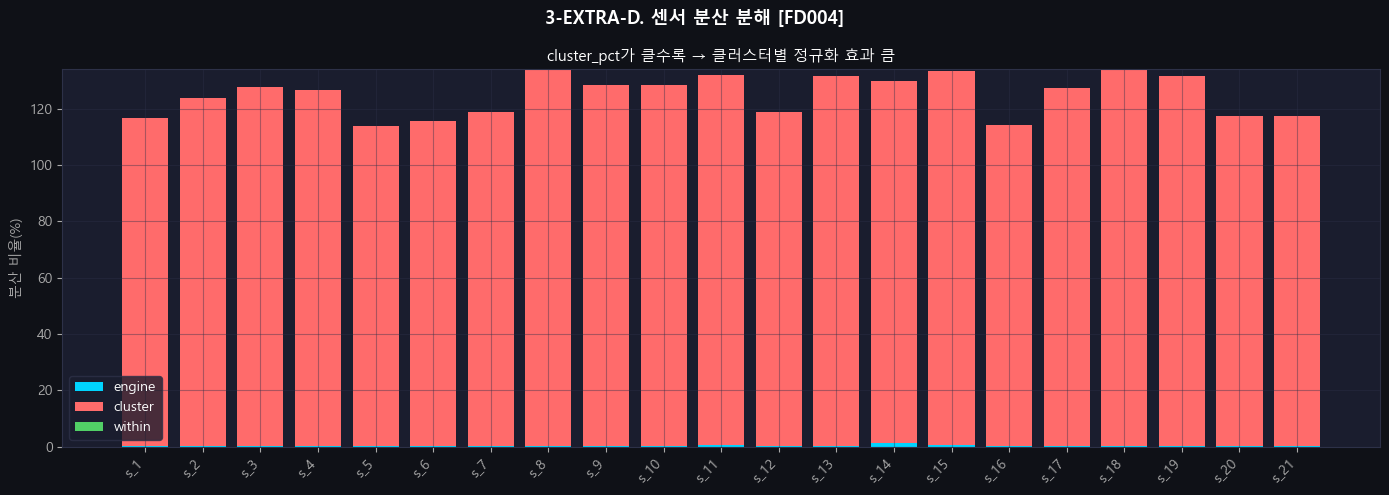

In [11]:
print('=== 3-EXTRA-D. 분산 분해 ===')

def var_decomp(df, sensor):
    total_var   = df[sensor].var()
    if total_var < 1e-9: return None
    engine_means  = df.groupby('unit_nr')[sensor].mean()
    cluster_means = df.groupby('op_cluster')[sensor].mean()
    var_engine  = engine_means.var()
    var_cluster = cluster_means.var()
    var_within  = max(total_var - var_engine - var_cluster, 0)
    return {'total': total_var, 'engine': var_engine,
            'cluster': var_cluster, 'within': var_within}

rows = []
for s in SENSOR_COLS:
    if train_raw[s].std() < 1e-6: continue
    d = var_decomp(train_raw, s)
    if d is None: continue
    rows.append({'센서': s,
                 'engine_pct':  round(d['engine'] /d['total']*100, 1),
                 'cluster_pct': round(d['cluster']/d['total']*100, 1),
                 'within_pct':  round(d['within'] /d['total']*100, 1)})

vd_df = pd.DataFrame(rows).set_index('센서')
display(vd_df.style.background_gradient(subset=['cluster_pct'], cmap='YlOrRd'))

fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('3-EXTRA-D. 센서 분산 분해 [FD004]', fontsize=13, fontweight='bold')
x = np.arange(len(vd_df))
ax.bar(x, vd_df['engine_pct'],  color=C[0], label='engine')
ax.bar(x, vd_df['cluster_pct'], bottom=vd_df['engine_pct'], color=C[1], label='cluster')
ax.bar(x, vd_df['within_pct'],
       bottom=vd_df['engine_pct']+vd_df['cluster_pct'], color=C[2], label='within')
ax.set_xticks(x); ax.set_xticklabels(vd_df.index, rotation=45, ha='right')
ax.set_ylabel('분산 비율(%)'); ax.legend()
ax.set_title('cluster_pct가 클수록 → 클러스터별 정규화 효과 큼')
plt.tight_layout(); plt.show()

### 3-EXTRA-E. Signal-to-Noise Ratio (SNR) per sensor — 클러스터 인식

=== 3-EXTRA-E. SNR per sensor (cluster-aware) ===


,SNR_mean,|SNR|_mean,SNR_std,설명
센서,,,,
s_11,2.155000,2.155000,0.065000,Ps30 정적압력(psia)
s_4,2.045000,2.045000,0.099000,T50 LPT 출구 온도(°R)
s_17,1.892000,1.892000,0.100000,htBleed 블리드 엔탈피
s_3,1.826000,1.826000,0.097000,T30 HPC 출구 온도(°R)
s_9,1.678000,1.678000,0.021000,Nc 코어 속도(rpm)
s_2,1.669000,1.669000,0.166000,T24 LPC 출구 온도(°R)
s_13,1.624000,1.624000,0.422000,NRf 보정 팬 속도(rpm)
s_8,1.621000,1.621000,0.426000,Nf 팬 속도(rpm)
s_14,1.452000,1.452000,0.035000,NRc 보정 코어속도(rpm)


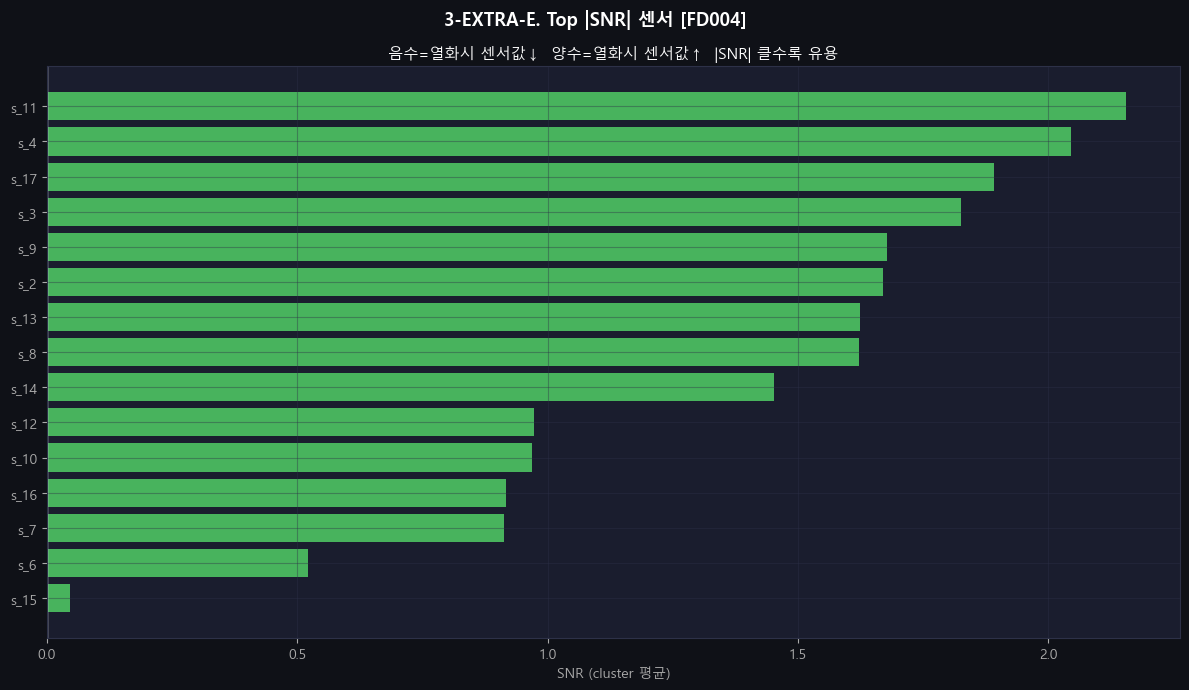

In [12]:
print('=== 3-EXTRA-E. SNR per sensor (cluster-aware) ===')

mc = train_raw.groupby('unit_nr')['time_cycles'].max().rename('max_c')
snr_src = train_raw.join(mc, on='unit_nr')
snr_src['RUL'] = snr_src['max_c'] - snr_src['time_cycles']

snr_rows = []
for s in SENSOR_COLS:
    cluster_snrs = []
    for c in range(N_CLUSTERS):
        sub = snr_src[snr_src['op_cluster']==c]
        if len(sub) < 50: continue
        early = sub[sub['RUL'] > sub['RUL'].quantile(0.8)][s].mean()
        late  = sub[sub['RUL'] < sub['RUL'].quantile(0.2)][s].mean()
        std   = sub[s].std()
        if std > 1e-6:
            cluster_snrs.append((late - early) / std)
    if cluster_snrs:
        snr_rows.append({'센서': s,
                         'SNR_mean':   round(np.mean(cluster_snrs), 3),
                         '|SNR|_mean': round(np.mean(np.abs(cluster_snrs)), 3),
                         'SNR_std':    round(np.std(cluster_snrs), 3),
                         '설명': SENSOR_DESC.get(s, s)})

snr_df = pd.DataFrame(snr_rows).set_index('센서').sort_values('|SNR|_mean', ascending=False)
display(snr_df.style.background_gradient(subset=['|SNR|_mean'], cmap='YlOrRd'))

fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle('3-EXTRA-E. Top |SNR| 센서 [FD004]', fontsize=13, fontweight='bold')
top = snr_df.head(15)
bc  = [C[2] if v>0 else C[1] for v in top['SNR_mean']]
ax.barh(top.index[::-1], top['SNR_mean'][::-1], color=bc[::-1], alpha=0.85)
ax.axvline(0, color='white', lw=1)
ax.set_xlabel('SNR (cluster 평균)')
ax.set_title('음수=열화시 센서값↓  양수=열화시 센서값↑  |SNR| 클수록 유용')
plt.tight_layout(); plt.show()

### 3-EXTRA-F. [FD004 전용 ★] Fan vs HPC 이중 고장 모드 센서 비교

FD003(단일 HPC+Fan, 단일 조건)과 달리 FD004는 **6가지 조건에서 두 고장 모드가 동시 진행**.
Fan 관련 센서(s_8, s_13, s_15)와 HPC 관련 센서(s_3, s_7, s_9, s_11, s_12)의
열화 트렌드를 클러스터별로 비교하여 이중 고장 신호를 분석.

=== 3-EXTRA-F. Fan vs HPC 이중 고장 모드 센서 비교 [FD004 전용] ===


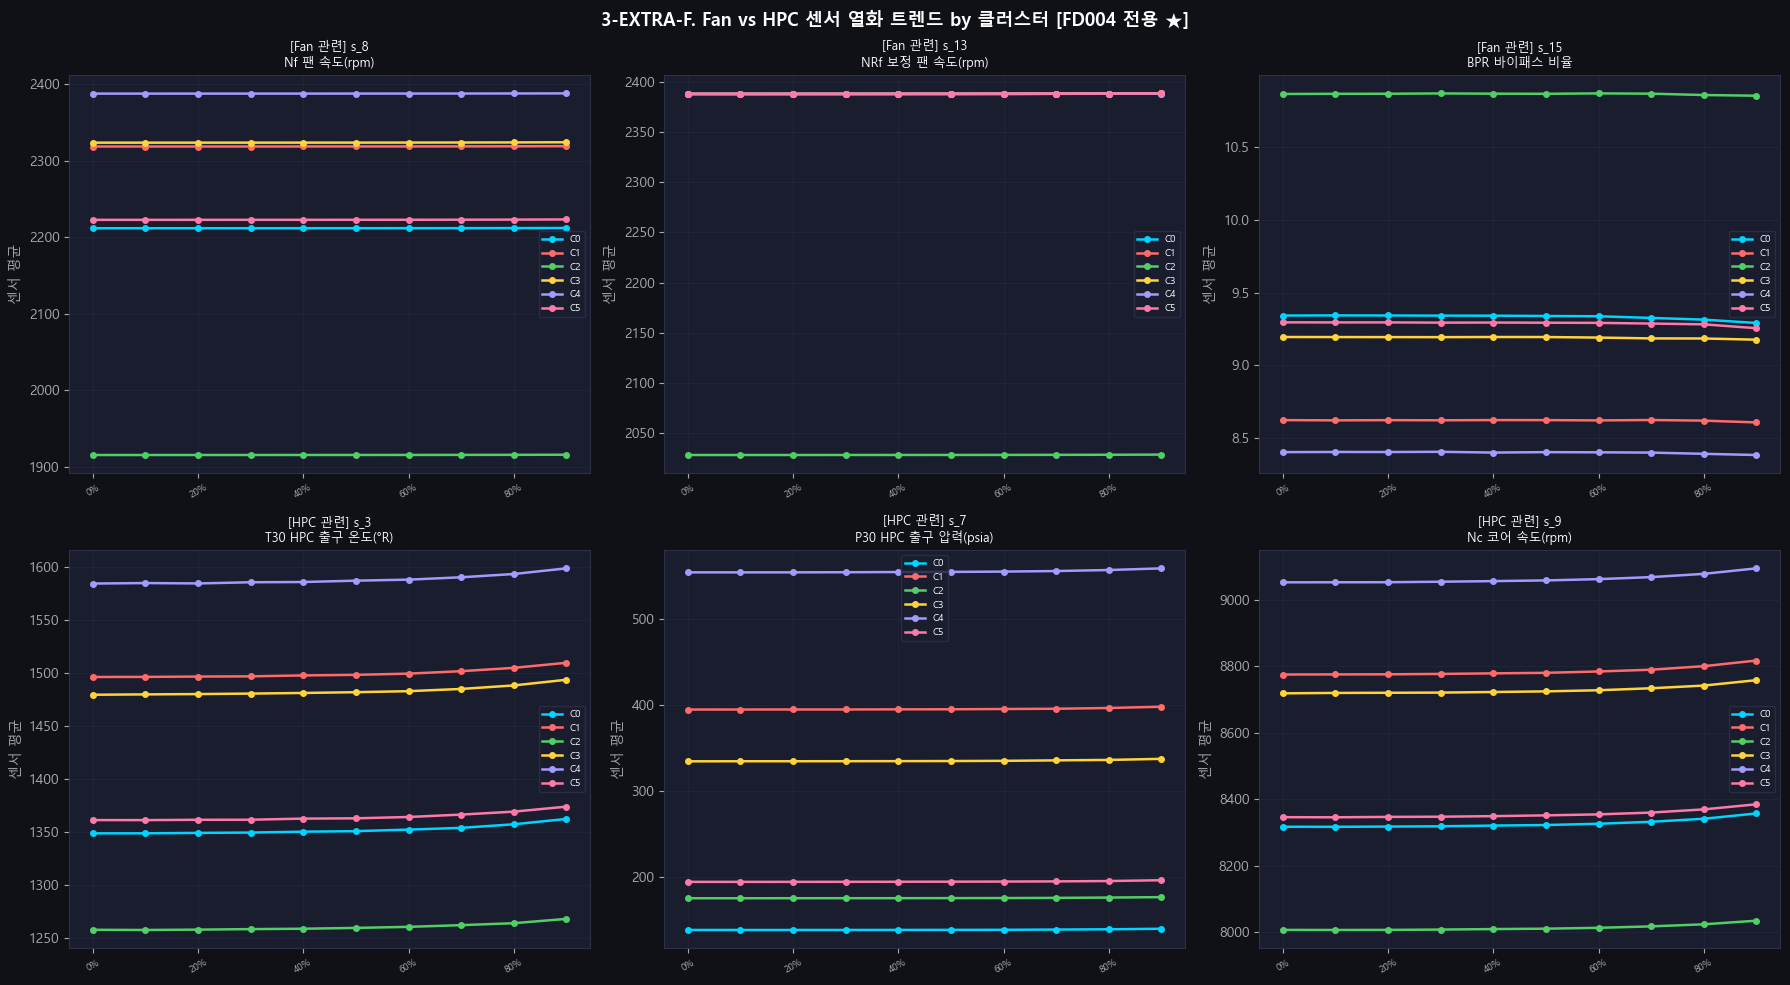


--- Fan vs HPC 센서 RUL 상관계수 (클러스터 평균) ---
  Fan 관련: {'s_8': np.float64(-0.509), 's_13': np.float64(-0.509), 's_15': np.float64(-0.022)}
  HPC 관련: {'s_3': np.float64(-0.583), 's_7': np.float64(-0.288), 's_9': np.float64(-0.523), 's_11': np.float64(-0.687), 's_12': np.float64(-0.308)}


In [13]:
print('=== 3-EXTRA-F. Fan vs HPC 이중 고장 모드 센서 비교 [FD004 전용] ===')

mc = train_raw.groupby('unit_nr')['time_cycles'].max().rename('max_c')
fd4_trj = train_raw.join(mc, on='unit_nr').copy()
fd4_trj['RUL'] = fd4_trj['max_c'] - fd4_trj['time_cycles']
fd4_trj['norm_life'] = fd4_trj['time_cycles'] / fd4_trj['max_c']

fan_useful   = [s for s in FAN_SENSORS  if s in USEFUL_SENSORS]
hpc_useful   = [s for s in HPC_SENSORS  if s in USEFUL_SENSORS]
fan_use = fan_useful[:3] if len(fan_useful)>=3 else fan_useful
hpc_use = hpc_useful[:3] if len(hpc_useful)>=3 else hpc_useful

fig, axes = plt.subplots(2, max(len(fan_use), len(hpc_use), 1), figsize=(18, 10))
fig.suptitle('3-EXTRA-F. Fan vs HPC 센서 열화 트렌드 by 클러스터 [FD004 전용 ★]',
             fontsize=13, fontweight='bold')

bins   = np.linspace(0, 1, 11)
labels = [f'{int(a*100)}%' for a in bins[:-1]]

for row_idx, (sensors_list, title) in enumerate([(fan_use, 'Fan 관련'), (hpc_use, 'HPC 관련')]):
    for col_idx, s in enumerate(sensors_list):
        if axes.ndim == 1:
            ax = axes[col_idx]
        else:
            ax = axes[row_idx, col_idx]
        fd4_trj['life_bin'] = pd.cut(fd4_trj['norm_life'], bins=bins, labels=labels)
        for c in range(N_CLUSTERS):
            sub = fd4_trj[fd4_trj['op_cluster']==c]
            means = sub.groupby('life_bin', observed=True)[s].mean()
            ax.plot(range(len(means)), means.values,
                    color=CLUSTER_COLORS[c], lw=1.8, marker='o', markersize=4, label=f'C{c}')
        ax.set_title(f'[{title}] {s}\n{SENSOR_DESC.get(s,s)}', fontsize=9)
        ax.set_xticks(range(0, 10, 2))
        ax.set_xticklabels([labels[i] for i in range(0,10,2)], rotation=30, fontsize=7)
        ax.set_ylabel('센서 평균'); ax.legend(fontsize=7)

plt.tight_layout(); plt.show()

# Fan vs HPC: 클러스터별 RUL 상관 비교
print('\n--- Fan vs HPC 센서 RUL 상관계수 (클러스터 평균) ---')
for group_name, group_sensors in [('Fan 관련', fan_useful), ('HPC 관련', hpc_useful)]:
    if not group_sensors: continue
    cluster_corrs = []
    for c in range(N_CLUSTERS):
        sub = fd4_trj[fd4_trj['op_cluster']==c]
        if len(sub) < 50:
            continue
        c_corrs = sub[group_sensors + ['RUL']].corr()['RUL'][group_sensors]
        cluster_corrs.append(c_corrs)
    if cluster_corrs:
        avg = pd.concat(cluster_corrs, axis=1).mean(axis=1)
        print(f'  {group_name}: {dict(avg.round(3))}')

---
## 4. 전처리 전 EDA

### 4-1. 기초 통계 & 데이터 품질

In [14]:
print('=== 기초 통계 & 데이터 품질 검사 ===')
quality = pd.DataFrame({
    '구분':     ['Train', 'Test'],
    '전체 행':  [len(train_raw), len(test_raw)],
    '결측치':   [train_raw.isnull().sum().sum(), test_raw.isnull().sum().sum()],
    '중복 행':  [train_raw.duplicated().sum(), test_raw.duplicated().sum()],
    '음수 센서':[(train_raw[SENSOR_COLS]<0).sum().sum(), (test_raw[SENSOR_COLS]<0).sum().sum()],
    '엔진 수':  [train_raw['unit_nr'].nunique(), test_raw['unit_nr'].nunique()],
    '운전 조건':[train_raw['op_cluster'].nunique(), test_raw['op_cluster'].nunique()],
    '판정':     ['✅ 정상', '✅ 정상'],
}).set_index('구분')
display(quality)

desc = train_raw[SENSOR_COLS].describe().T
desc['CV(변동계수)'] = (desc['std'] / desc['mean'].abs()).round(5)
print('\n--- 센서별 기술통계 (Train 전체) ---')
display(desc[['mean','std','min','max','CV(변동계수)']].style
        .background_gradient(subset=['CV(변동계수)'], cmap='YlOrRd').format('{:.4f}'))
print('\n📌 CV≈0 → 상수 센서, FD004에서 제거 대상 확인')
print('📌 FD004: 6가지 운전 조건 혼재로 CV가 단일 조건보다 높게 나타남')

=== 기초 통계 & 데이터 품질 검사 ===


,전체 행,결측치,중복 행,음수 센서,엔진 수,운전 조건,판정
구분,,,,,,,
Train,61249,0,0,0,249,6,✅ 정상
Test,41214,0,0,0,248,6,✅ 정상



--- 센서별 기술통계 (Train 전체) ---


,mean,std,min,max,CV(변동계수)
s_1,472.8824,26.4368,445.0000,518.6700,0.0559
s_2,579.4201,37.3426,535.4800,644.4200,0.0644
s_3,1417.8966,106.1676,1242.6700,1613.0000,0.0749
s_4,1201.9154,119.3276,1024.4200,1440.7700,0.0993
s_5,8.0316,3.6229,3.9100,14.6200,0.4511
s_6,11.5895,5.4440,5.6700,21.6100,0.4697
s_7,283.3286,146.8802,136.1700,570.8100,0.5184
s_8,2228.6860,145.3482,1914.7200,2388.6400,0.0652
s_9,8524.6733,336.9275,7984.5100,9196.8100,0.0395
s_10,1.0964,0.1277,0.9300,1.3200,0.1164



📌 CV≈0 → 상수 센서, FD004에서 제거 대상 확인
📌 FD004: 6가지 운전 조건 혼재로 CV가 단일 조건보다 높게 나타남


### 4-2. 엔진 수명 분포 & RUL Cap 탐색

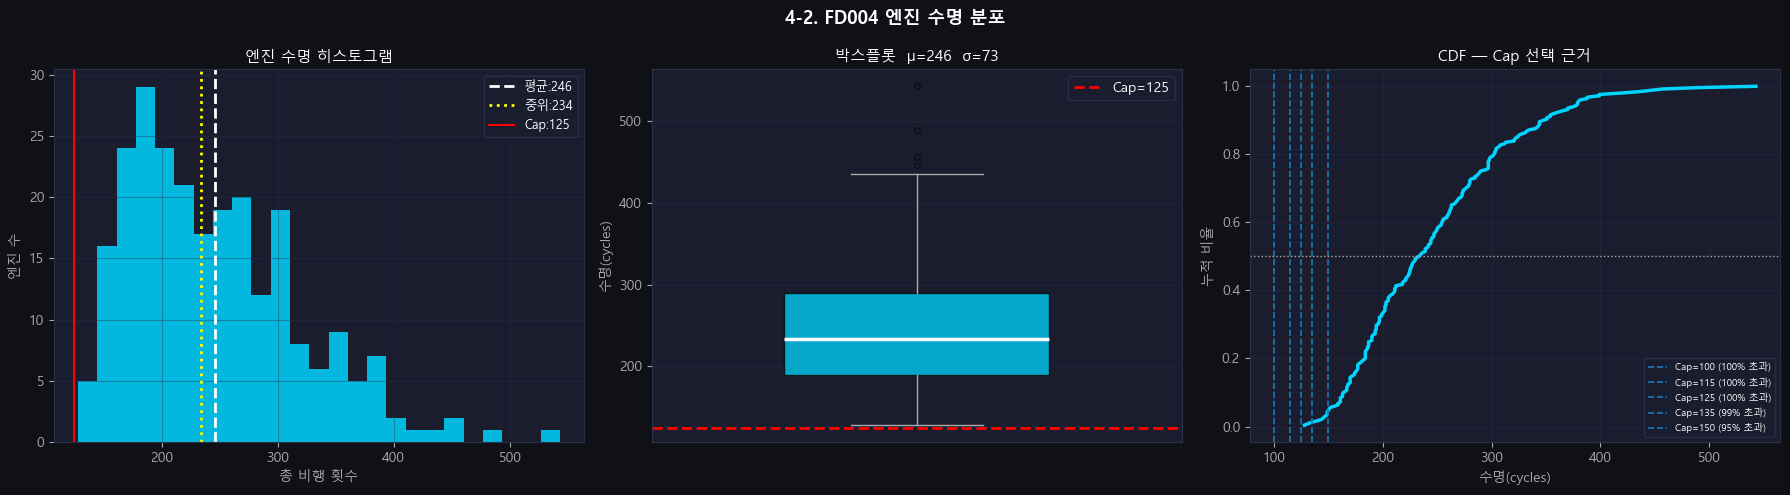


엔진 수명 통계:
  평균=246.0  중위=234.0  min=128  max=543
  Cap=100: 초과 엔진 100.0%
  Cap=115: 초과 엔진 100.0%
  Cap=125: 초과 엔진 100.0%
  Cap=135: 초과 엔진 98.8%
  Cap=150: 초과 엔진 95.2%


In [15]:
lifecycles = train_raw.groupby('unit_nr')['time_cycles'].max()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('4-2. FD004 엔진 수명 분포', fontsize=13, fontweight='bold')

axes[0].hist(lifecycles, bins=25, color=C[0], alpha=0.85, edgecolor='none')
axes[0].axvline(lifecycles.mean(),   color='white',  ls='--', lw=2, label=f'평균:{lifecycles.mean():.0f}')
axes[0].axvline(lifecycles.median(), color='yellow', ls=':',  lw=2, label=f'중위:{lifecycles.median():.0f}')
axes[0].axvline(RUL_CAP, color='red', ls='-', lw=1.5, label=f'Cap:{RUL_CAP}')
axes[0].set_xlabel('총 비행 횟수'); axes[0].set_ylabel('엔진 수')
axes[0].set_title('엔진 수명 히스토그램'); axes[0].legend(fontsize=9)

bp = axes[1].boxplot(lifecycles, patch_artist=True, vert=True, widths=0.5,
                     medianprops=dict(color='white', lw=2.5),
                     whiskerprops=dict(color=GRAY), capprops=dict(color=GRAY),
                     flierprops=dict(marker='o', color=GRAY, markersize=4, alpha=0.5))
bp['boxes'][0].set_facecolor(C[0]); bp['boxes'][0].set_alpha(0.75)
axes[1].axhline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
axes[1].set_ylabel('수명(cycles)'); axes[1].set_title(f'박스플롯  μ={lifecycles.mean():.0f}  σ={lifecycles.std():.0f}')
axes[1].set_xticks([]); axes[1].legend()

lc_sorted = np.sort(lifecycles); cdf = np.arange(1, len(lc_sorted)+1)/len(lc_sorted)
axes[2].plot(lc_sorted, cdf, color=C[0], lw=2.5)
for cap in [100, 115, 125, 135, 150]:
    pct = (lifecycles <= cap).mean()
    axes[2].axvline(cap, ls='--', lw=1.2, label=f'Cap={cap} ({(1-pct)*100:.0f}% 초과)')
axes[2].axhline(0.5, color=GRAY, ls=':', lw=1)
axes[2].set_xlabel('수명(cycles)'); axes[2].set_ylabel('누적 비율')
axes[2].set_title('CDF — Cap 선택 근거'); axes[2].legend(fontsize=7)
plt.tight_layout(); plt.show()

print('\n엔진 수명 통계:')
print(f'  평균={lifecycles.mean():.1f}  중위={lifecycles.median():.1f}  min={lifecycles.min()}  max={lifecycles.max()}')
for cap in [100, 115, 125, 135, 150]:
    pct = (lifecycles > cap).mean()*100
    print(f'  Cap={cap}: 초과 엔진 {pct:.1f}%')

### 4-3. 클러스터별 운전 조건 분포 시각화 [FD004]

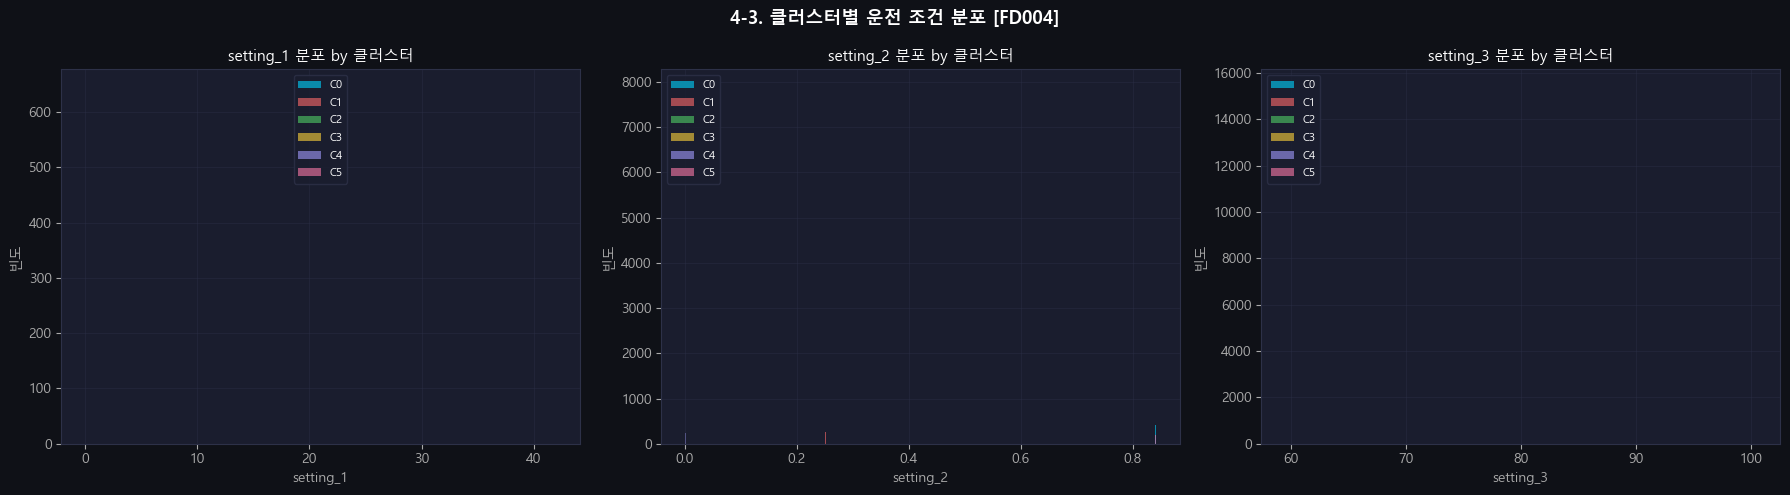


--- 클러스터 내 운전 조건 표준편차 (작을수록 클러스터링 품질 우수) ---


,setting_1,setting_2,setting_3
op_cluster,,,
0,0.00289,0.00064,0.0
1,0.00291,0.00064,0.0
2,0.00290,0.00065,0.0
3,0.00289,0.00065,0.0
4,0.00087,0.00065,0.0
5,0.00288,0.00065,0.0


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('4-3. 클러스터별 운전 조건 분포 [FD004]', fontsize=13, fontweight='bold')

for ax, op in zip(axes, OP_COLS):
    for c in range(N_CLUSTERS):
        mask = train_raw['op_cluster'] == c
        ax.hist(train_raw.loc[mask, op], bins=30, alpha=0.6,
                color=CLUSTER_COLORS[c], label=f'C{c}', edgecolor='none')
    ax.set_title(f'{op} 분포 by 클러스터')
    ax.set_xlabel(op); ax.set_ylabel('빈도'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print('\n--- 클러스터 내 운전 조건 표준편차 (작을수록 클러스터링 품질 우수) ---')
intra_std = train_raw.groupby('op_cluster')[OP_COLS].std()
display(intra_std.round(5))

### 4-4. 센서 분포 & 이상치 (전처리 전)

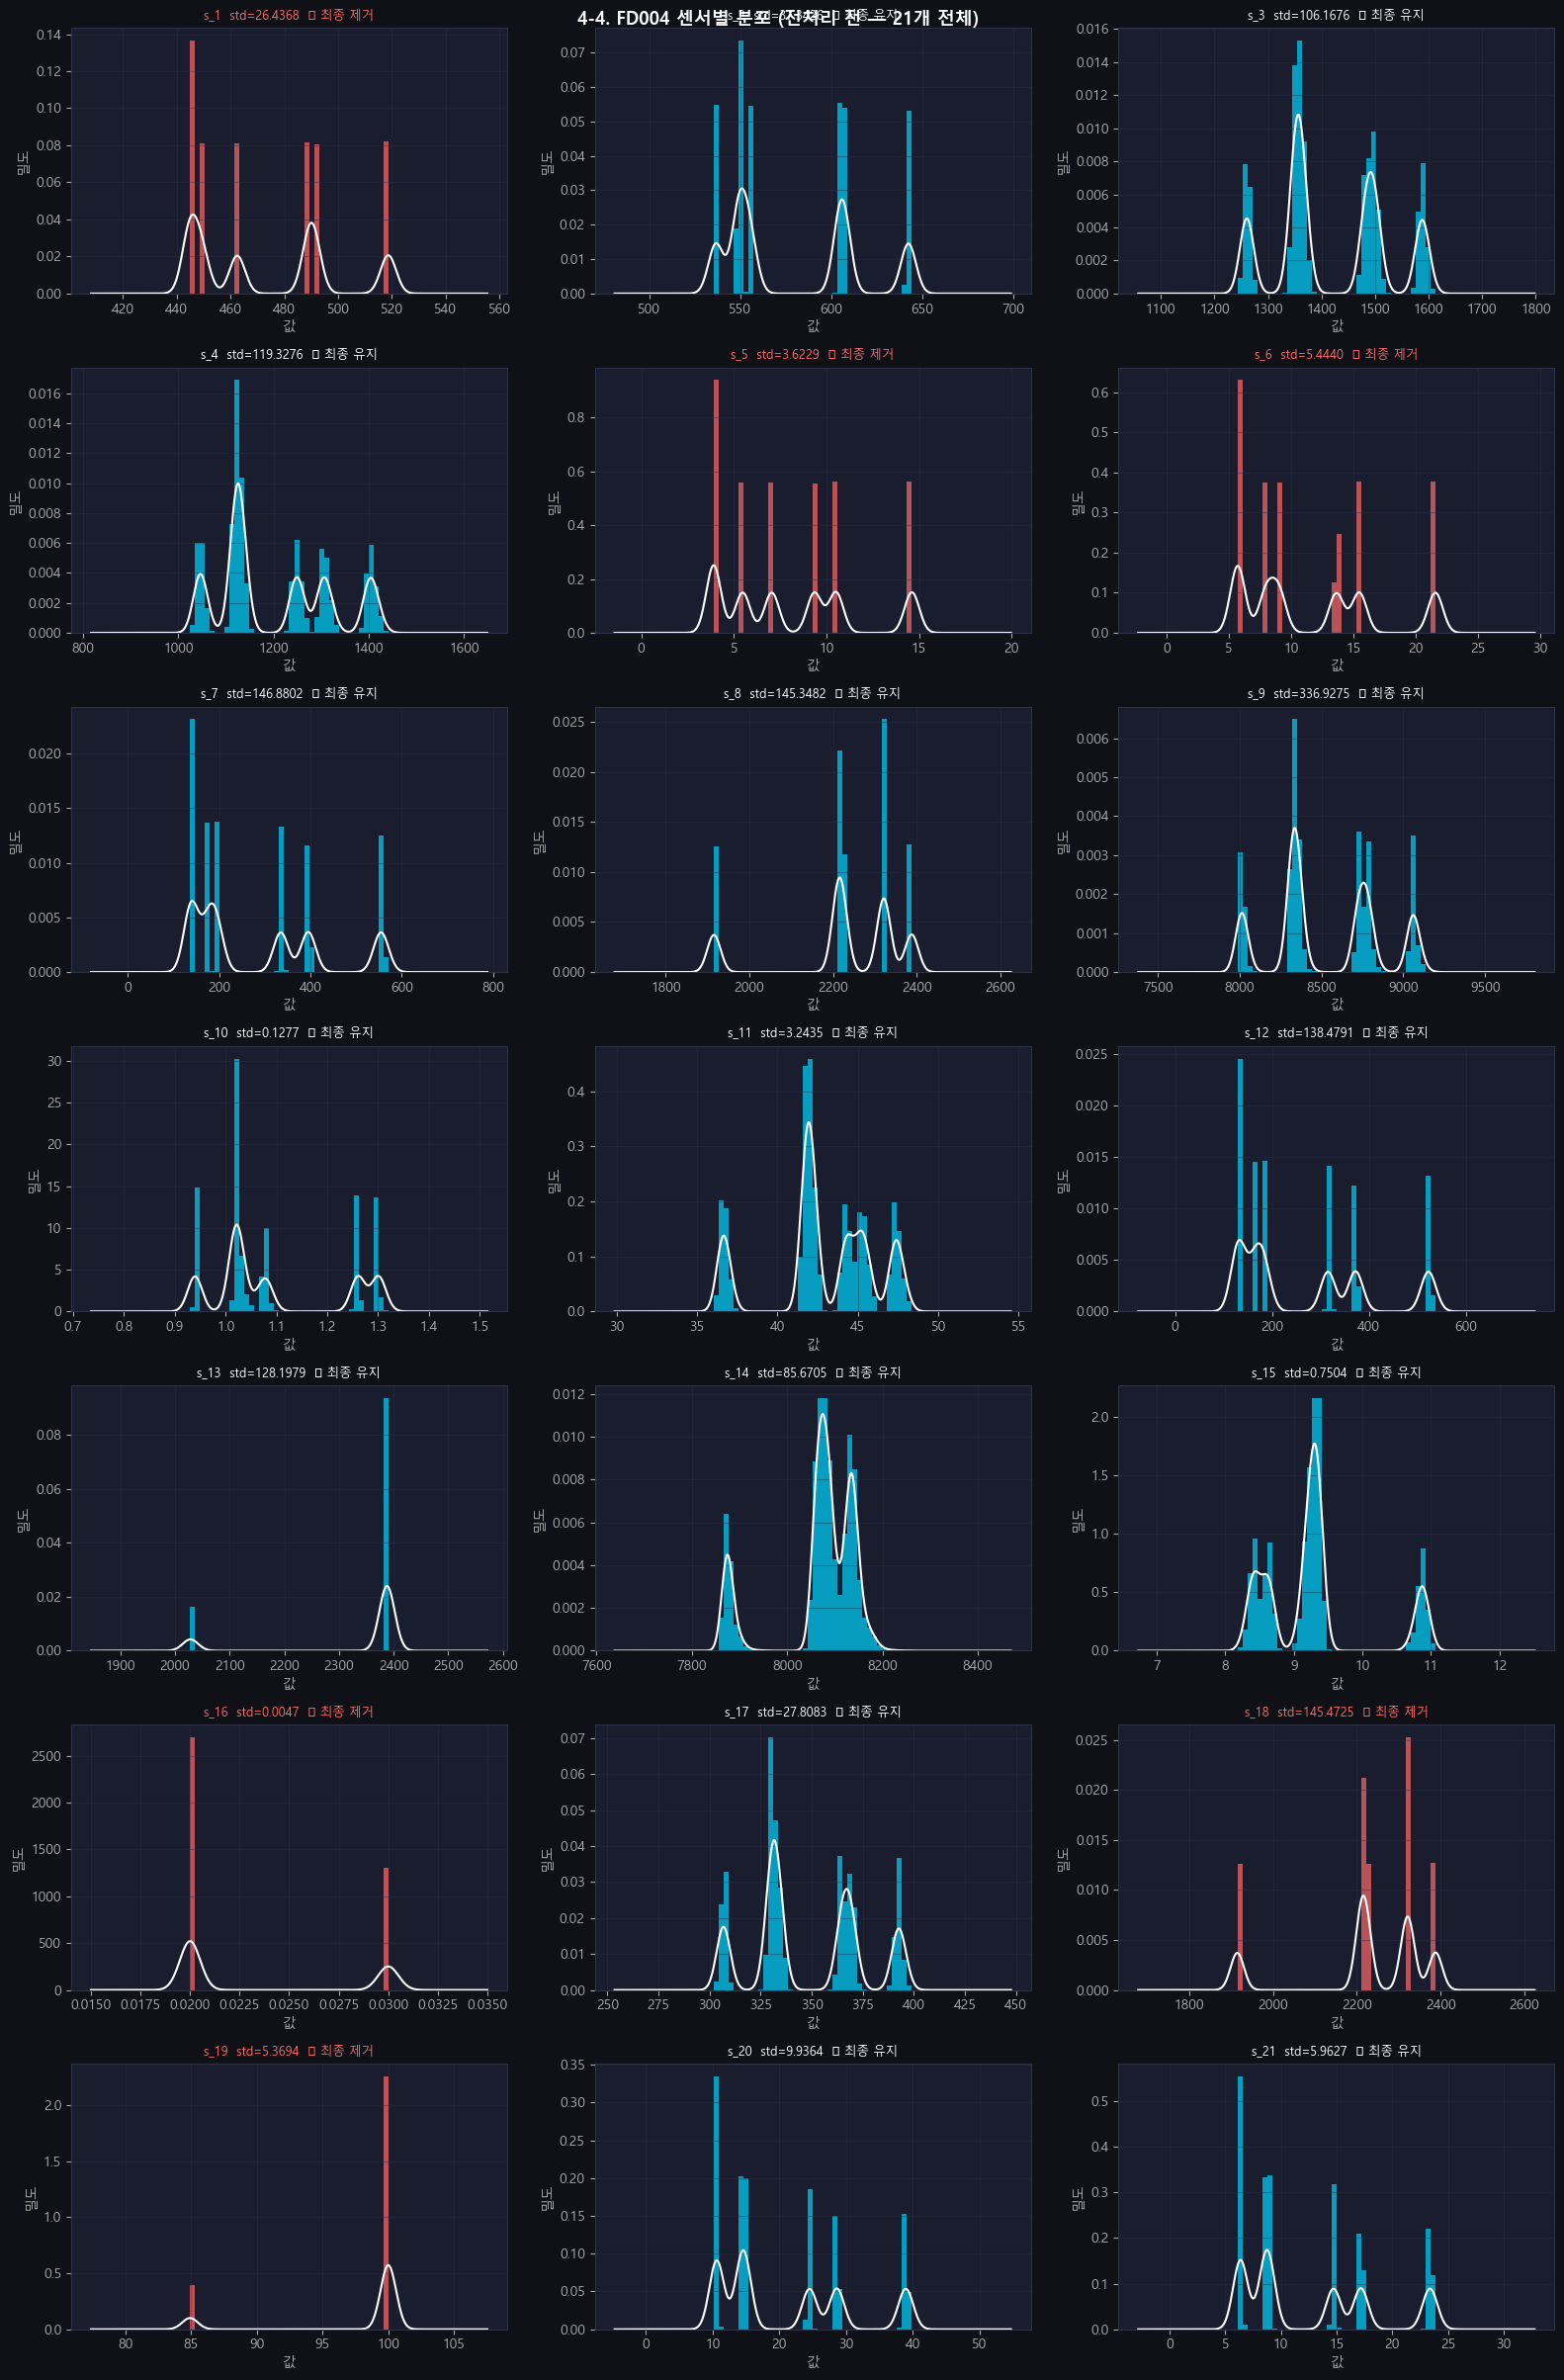

--- IQR 기준 이상치 탐지 ---


,센서,이상치 수,비율(%)
7,s_8,9139,14.921
10,s_11,3102,5.065
12,s_13,11546,18.851
13,s_14,9162,14.959
14,s_15,9139,14.921
17,s_18,9139,14.921
18,s_19,9139,14.921


In [17]:
n_cols, n_rows = 3, 7
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*3.5))
fig.suptitle('4-4. FD004 센서별 분포 (전처리 전 — 21개 전체)', fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, SENSOR_COLS):
    data = train_raw[s].dropna()
    std_val = data.std()
    is_remove = s in REMOVE_SENSORS
    color = C[1] if is_remove else C[0]
    ax.hist(data, bins=40, color=color, alpha=0.7, density=True, edgecolor='none')
    try: data.plot.kde(ax=ax, color='white', lw=1.5)
    except: pass
    label = '❌ 최종 제거' if is_remove else '✅ 최종 유지'
    ax.set_title(f'{s}  std={std_val:.4f}  {label}', fontsize=9,
                 color=C[1] if is_remove else WHITE)
    ax.set_xlabel('값'); ax.set_ylabel('밀도')

for ax in axes.flat[len(SENSOR_COLS):]: ax.set_visible(False)
plt.tight_layout(); plt.show()

print('--- IQR 기준 이상치 탐지 ---')
outlier_rows = []
for s in SENSOR_COLS:
    Q1, Q3 = train_raw[s].quantile(0.25), train_raw[s].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((train_raw[s] < Q1-1.5*IQR)|(train_raw[s] > Q3+1.5*IQR)).sum()
    outlier_rows.append({'센서': s, '이상치 수': n_out,
                         '비율(%)': round(n_out/len(train_raw)*100, 3)})
out_df = pd.DataFrame(outlier_rows)
nonzero = out_df[out_df['이상치 수']>0]
if len(nonzero): display(nonzero)
else: print('✅ IQR 기준 이상치 없음 (시뮬레이션 데이터 특성)')

### 4-5. 클러스터별 센서 분포 비교 & Kruskal-Wallis [FD004]

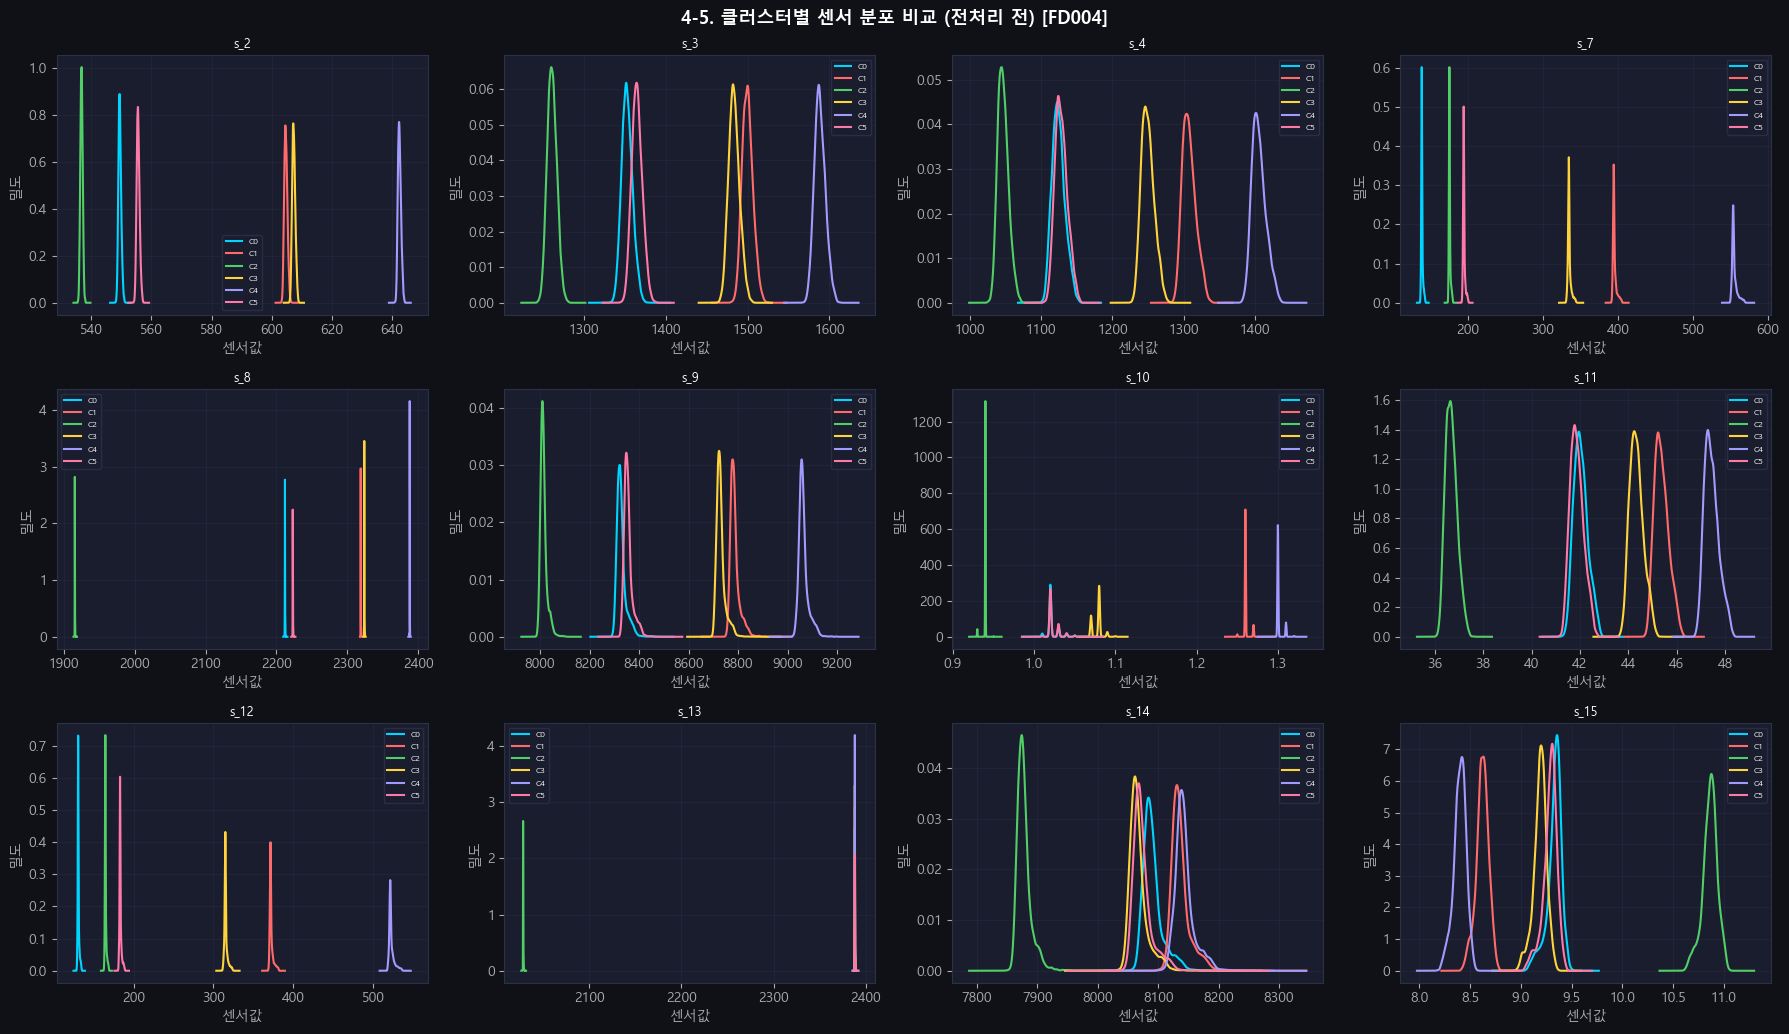

--- Kruskal-Wallis: 클러스터 간 센서 분포 차이 ---


,센서,H통계량,p-value,클러스터별 정규화 필요,p_adj_BH,판정_BH
0,s_1,61248.00,0.0,🔴 필수,0.0,✅ 유의(FDR)
1,s_2,59246.97,0.0,🔴 필수,0.0,✅ 유의(FDR)
2,s_3,58112.26,0.0,🔴 필수,0.0,✅ 유의(FDR)
3,s_4,56635.10,0.0,🔴 필수,0.0,✅ 유의(FDR)
4,s_5,61248.00,0.0,🔴 필수,0.0,✅ 유의(FDR)
5,s_6,59448.48,0.0,🔴 필수,0.0,✅ 유의(FDR)
6,s_7,59247.34,0.0,🔴 필수,0.0,✅ 유의(FDR)
7,s_8,59248.20,0.0,🔴 필수,0.0,✅ 유의(FDR)
8,s_9,58070.51,0.0,🔴 필수,0.0,✅ 유의(FDR)
9,s_10,58531.83,0.0,🔴 필수,0.0,✅ 유의(FDR)



클러스터간 유의 (BH-FDR<0.05): 21/21개
📌 대부분 유의 → 클러스터별 정규화 반드시 필요


In [18]:
show_sensors = USEFUL_SENSORS[:12]
n_cols = 4; n_rows = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*3.5))
fig.suptitle('4-5. 클러스터별 센서 분포 비교 (전처리 전) [FD004]',
             fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, show_sensors):
    for c in range(N_CLUSTERS):
        mask = train_raw['op_cluster'] == c
        data = train_raw.loc[mask, s].dropna()
        if len(data) > 1:
            try: data.plot.kde(ax=ax, color=CLUSTER_COLORS[c], lw=1.5, label=f'C{c}')
            except: pass
    ax.set_title(f'{s}', fontsize=9)
    ax.set_xlabel('센서값'); ax.set_ylabel('밀도'); ax.legend(fontsize=6)

for ax in axes.flat[len(show_sensors):]: ax.set_visible(False)
plt.tight_layout(); plt.show()

# Kruskal-Wallis + BH-FDR
print('--- Kruskal-Wallis: 클러스터 간 센서 분포 차이 ---')
kw_rows = []
for s in SENSOR_COLS:
    groups = [train_raw[train_raw['op_cluster']==c][s].dropna().values for c in range(N_CLUSTERS)]
    groups = [g for g in groups if len(g) > 1]
    if len(groups) >= 2:
        h_stat, p_val = kruskal(*groups)
    else:
        h_stat, p_val = np.nan, np.nan
    kw_rows.append({'센서': s, 'H통계량': round(h_stat,2) if np.isfinite(h_stat) else np.nan,
                    'p-value': round(p_val,4) if np.isfinite(p_val) else np.nan,
                    '클러스터별 정규화 필요': '🔴 필수' if (np.isfinite(p_val) and p_val<0.05) else '🟢 불필요'})

kw_df = pd.DataFrame(kw_rows)
_pvals = kw_df['p-value'].fillna(1.0).values
_rej, _padj, *_ = multipletests(_pvals, alpha=0.05, method='fdr_bh')
kw_df['p_adj_BH'] = np.round(_padj, 4)
kw_df['판정_BH']  = ['✅ 유의(FDR)' if r else '⚠️ 비유의(FDR)' for r in _rej]
display(kw_df)
print(f"\n클러스터간 유의 (BH-FDR<0.05): {sum(_rej)}/{len(kw_df)}개")
print('📌 대부분 유의 → 클러스터별 정규화 반드시 필요')

### 4-6. 센서 간 상관관계 히트맵 (전처리 전)

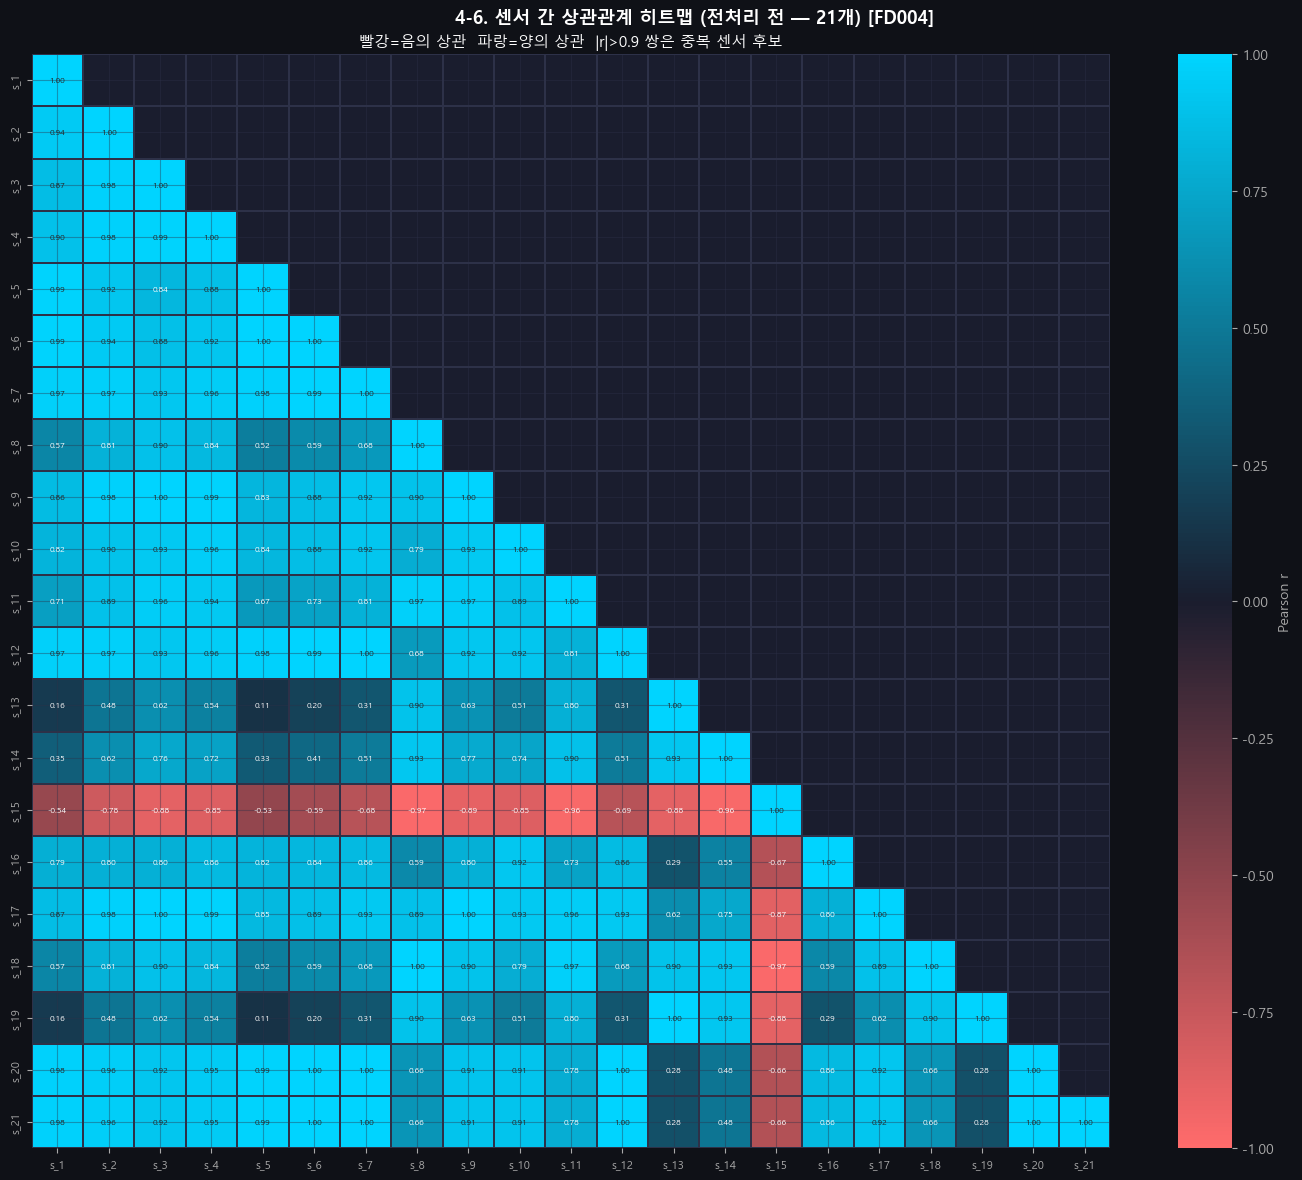

고상관 쌍 (|r|>0.9): 87개


,센서A,센서B,r
0,s_1,s_2,0.944
1,s_1,s_5,0.987
2,s_1,s_6,0.987
3,s_1,s_7,0.973
4,s_1,s_12,0.973
...,...,...,...
82,s_15,s_18,-0.969
83,s_17,s_20,0.919
84,s_17,s_21,0.919
85,s_18,s_19,0.903


In [19]:
corr_before = train_raw[SENSOR_COLS].corr()

fig, ax = plt.subplots(figsize=(14, 12))
fig.suptitle('4-6. 센서 간 상관관계 히트맵 (전처리 전 — 21개) [FD004]',
             fontsize=13, fontweight='bold')

mask = np.triu(np.ones_like(corr_before, dtype=bool), k=1)
sns.heatmap(corr_before, ax=ax, mask=mask, cmap=cmap_rg, center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size': 6}, linewidths=0.3, linecolor=GRID,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('빨강=음의 상관  파랑=양의 상관  |r|>0.9 쌍은 중복 센서 후보')
ax.tick_params(labelsize=8)
plt.tight_layout(); plt.show()

pairs = []
for i in range(len(SENSOR_COLS)):
    for j in range(i+1, len(SENSOR_COLS)):
        r = corr_before.iloc[i, j]
        if abs(r) > 0.9:
            pairs.append({'센서A': SENSOR_COLS[i], '센서B': SENSOR_COLS[j], 'r': round(r,3)})
print(f'고상관 쌍 (|r|>0.9): {len(pairs)}개')
if pairs: display(pd.DataFrame(pairs))

### 4-7. 센서별 열화 트렌드 (클러스터별 r 평균 기준)

적용 임계값 |r|>0.1 → 13개 센서


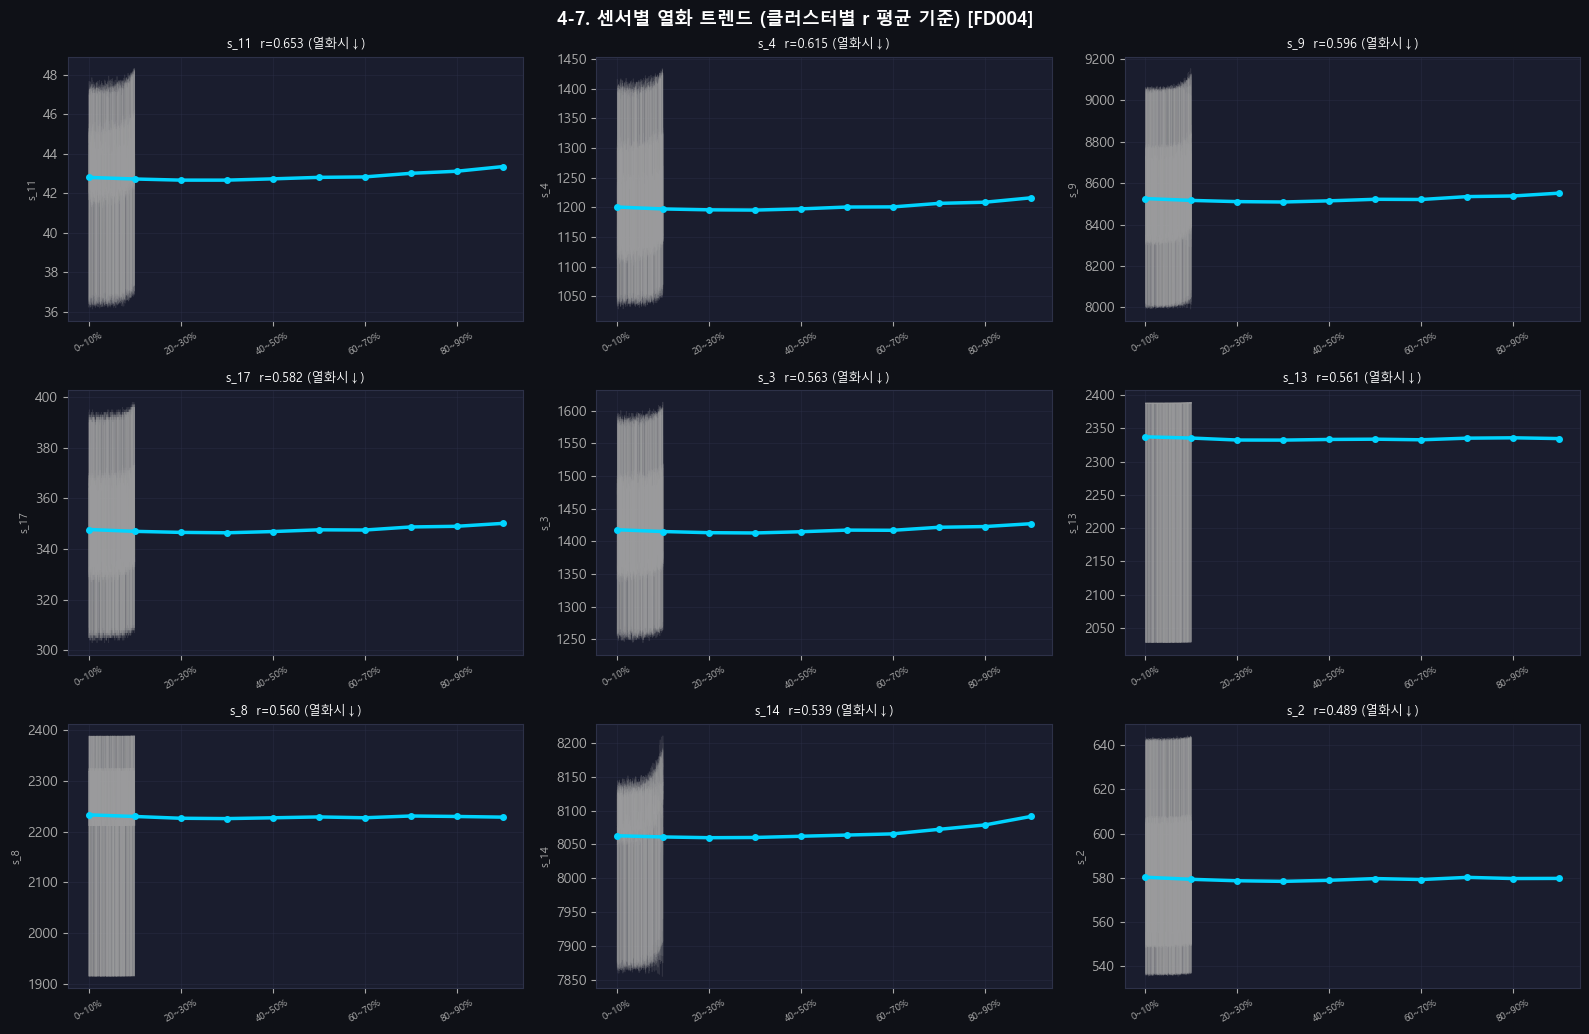

In [20]:
mc = train_raw.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_trend = train_raw.join(mc, on='unit_nr')
tr_trend['norm_life'] = tr_trend['time_cycles'] / tr_trend['max_c']
tr_trend['RUL']       = tr_trend['max_c'] - tr_trend['time_cycles']

bins   = np.linspace(0, 1, 11)
labels_life = [f'{int(a*100)}~{int(b*100)}%' for a,b in zip(bins[:-1], bins[1:])]
tr_trend['life_bin'] = pd.cut(tr_trend['norm_life'], bins=bins, labels=labels_life)
trend_mean = tr_trend.groupby('life_bin', observed=True)[SENSOR_COLS].mean()

# 클러스터별 상관 평균 (운전 조건 혼재 보정)
cluster_corrs = []
for c in range(N_CLUSTERS):
    sub = tr_trend[tr_trend['op_cluster']==c]
    if len(sub) > 10:
        corr_c = sub[SENSOR_COLS + ['norm_life']].corr()['norm_life'][SENSOR_COLS]
        cluster_corrs.append(corr_c)
corr_with_life = pd.concat(cluster_corrs, axis=1).mean(axis=1)

trend_sensors = []
for thr in [0.1, 0.05, 0.01, 0.0]:
    trend_sensors = corr_with_life[corr_with_life.abs() > thr].sort_values(key=abs, ascending=False).index.tolist()
    if trend_sensors:
        print(f'적용 임계값 |r|>{thr} → {len(trend_sensors)}개 센서'); break

trend_sensors = trend_sensors[:9]
n_c = 3; n_r = max(1, (len(trend_sensors)+n_c-1)//n_c)
fig, axes = plt.subplots(n_r, n_c, figsize=(16, n_r*3.5))
fig.suptitle('4-7. 센서별 열화 트렌드 (클러스터별 r 평균 기준) [FD004]',
             fontsize=13, fontweight='bold')

axes_list = list(np.array(axes).flat) if n_r*n_c > 1 else [axes]
x_pos = range(len(labels_life))
sample_units = tr_trend['unit_nr'].unique()[:15]

for ax, s in zip(axes_list, trend_sensors):
    for u in sample_units:
        sub = tr_trend[tr_trend['unit_nr']==u].sort_values('norm_life')
        ax.plot(sub['norm_life'], sub[s], color=GRAY, alpha=0.15, lw=0.6)
    ax.plot(x_pos, trend_mean[s].values, color=C[0], lw=2.5, marker='o', markersize=4)
    r = corr_with_life[s]
    direction = '열화시↑' if r < 0 else '열화시↓'
    ax.set_title(f'{s}  r={r:.3f} ({direction})', fontsize=9)
    ax.set_xticks(list(x_pos)[::2])
    ax.set_xticklabels(labels_life[::2], rotation=30, fontsize=7)
    ax.set_ylabel(s, fontsize=8)

for ax in axes_list[len(trend_sensors):]: ax.set_visible(False)
plt.tight_layout(); plt.show()

### 4-8. RUL 상관계수 (클러스터별 평균)

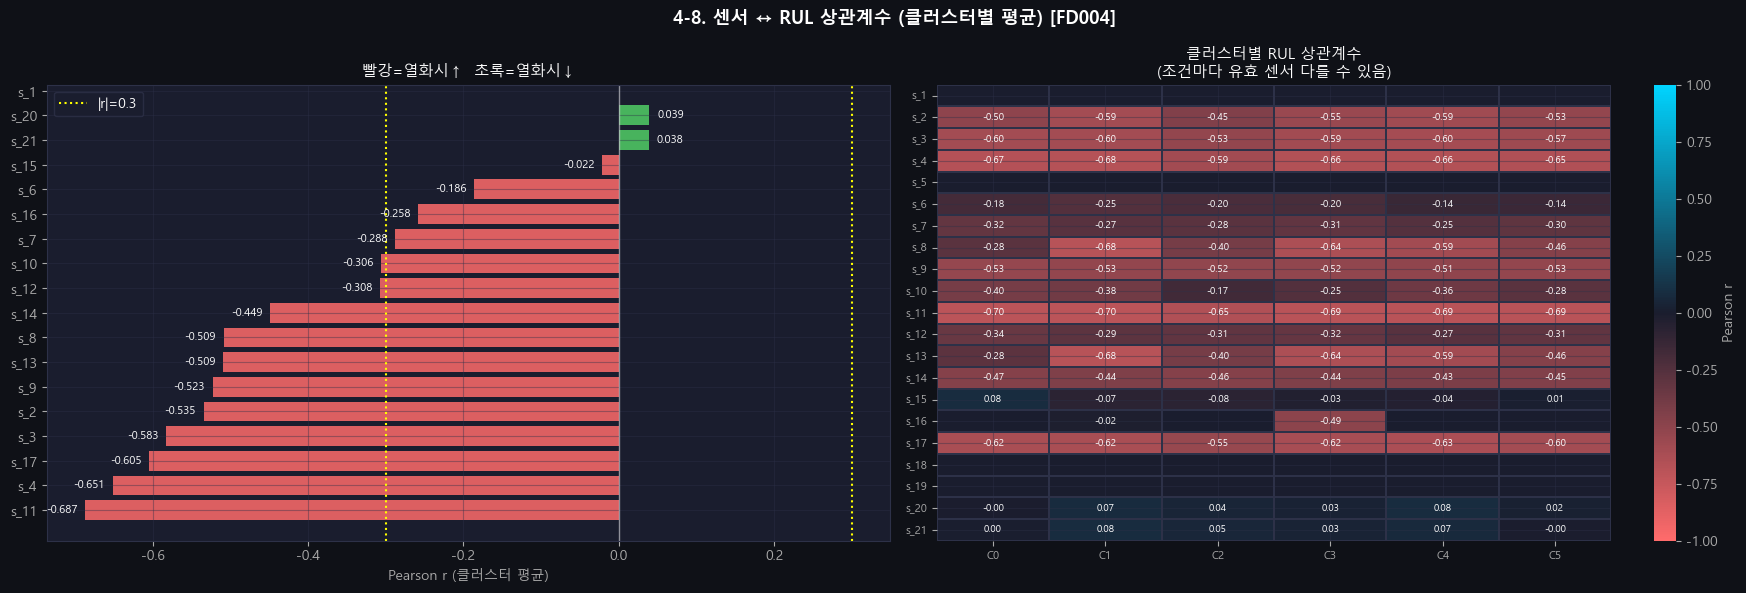


|r|>0.3 고상관 센서 (클러스터 평균): 11개
  s_11: r=-0.687  Ps30 정적압력(psia)
  s_4: r=-0.651  T50 LPT 출구 온도(°R)
  s_17: r=-0.605  htBleed 블리드 엔탈피
  s_3: r=-0.583  T30 HPC 출구 온도(°R)
  s_2: r=-0.535  T24 LPC 출구 온도(°R)
  s_9: r=-0.523  Nc 코어 속도(rpm)
  s_13: r=-0.509  NRf 보정 팬 속도(rpm)
  s_8: r=-0.509  Nf 팬 속도(rpm)
  s_14: r=-0.449  NRc 보정 코어속도(rpm)
  s_12: r=-0.308  phi 연료/Ps30 비율
  s_10: r=-0.306  epr 엔진 압력비


In [21]:
cluster_rul_corrs = []
for c in range(N_CLUSTERS):
    sub = tr_trend[tr_trend['op_cluster']==c]
    if len(sub) > 10:
        corr_c = sub[SENSOR_COLS + ['RUL']].corr()['RUL'][SENSOR_COLS]
        cluster_rul_corrs.append(corr_c)

rul_corr_before = pd.concat(cluster_rul_corrs, axis=1).mean(axis=1).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('4-8. 센서 ↔ RUL 상관계수 (클러스터별 평균) [FD004]',
             fontsize=13, fontweight='bold')

bar_colors = [C[1] if v<0 else C[2] for v in rul_corr_before]
bars = axes[0].barh(rul_corr_before.index, rul_corr_before.values, color=bar_colors, alpha=0.85)
axes[0].axvline(0, color='white', lw=1, alpha=0.5)
axes[0].axvline( 0.3, color='yellow', lw=1.5, ls=':', label='|r|=0.3')
axes[0].axvline(-0.3, color='yellow', lw=1.5, ls=':')
axes[0].set_xlabel('Pearson r (클러스터 평균)')
axes[0].set_title('빨강=열화시↑  초록=열화시↓')
axes[0].legend()
for bar, val in zip(bars, rul_corr_before.values):
    axes[0].text(val+(0.01 if val>=0 else -0.01), bar.get_y()+bar.get_height()/2,
                 f'{val:.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=8)

cluster_corr_matrix = pd.concat(cluster_rul_corrs, axis=1)
cluster_corr_matrix.columns = [f'C{i}' for i in range(len(cluster_rul_corrs))]
sns.heatmap(cluster_corr_matrix, ax=axes[1], cmap=cmap_rg, center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size': 7}, linewidths=0.3, linecolor=GRID,
            cbar_kws={'label': 'Pearson r'})
axes[1].set_title('클러스터별 RUL 상관계수\n(조건마다 유효 센서 다를 수 있음)')
axes[1].tick_params(labelsize=8)
plt.tight_layout(); plt.show()

high_corr = rul_corr_before[rul_corr_before.abs() > 0.3]
print(f'\n|r|>0.3 고상관 센서 (클러스터 평균): {len(high_corr)}개')
for s, r in high_corr.sort_values(key=abs, ascending=False).items():
    print(f'  {s}: r={r:.3f}  {SENSOR_DESC.get(s,"")}')

### 4-9. 시차 상관관계 (Sensor → RUL, lag 0~15)

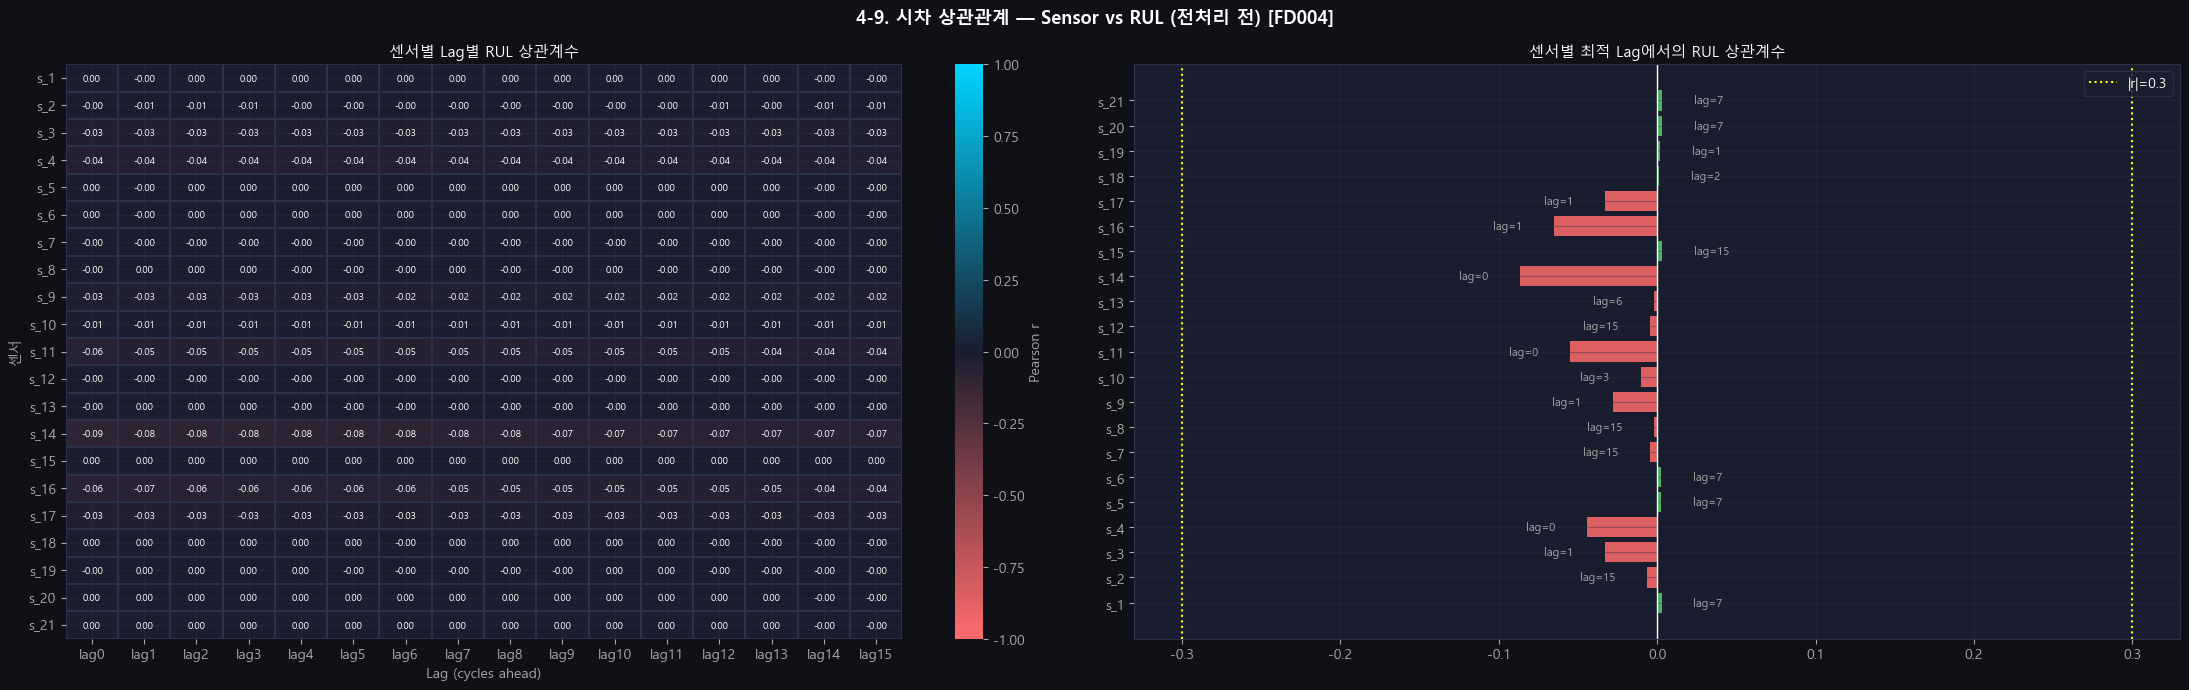

In [22]:
MAX_LAG = 15; LAGS = list(range(0, MAX_LAG+1))
lag_matrix = np.full((len(SENSOR_COLS), len(LAGS)), np.nan)

for si, s in enumerate(SENSOR_COLS):
    unit_lag = {lag: [] for lag in LAGS}
    for uid in tr_trend['unit_nr'].unique():
        udf    = tr_trend[tr_trend['unit_nr']==uid].sort_values('time_cycles')
        sensor = udf[s].values; rul = udf['RUL'].values
        for lag in LAGS:
            if len(sensor) > lag + 5:
                c_val = np.corrcoef(sensor[:len(sensor)-lag], rul[lag:])[0,1]
                if np.isfinite(c_val): unit_lag[lag].append(c_val)
    lag_matrix[si] = [np.mean(unit_lag[l]) if unit_lag[l] else np.nan for l in LAGS]

lag_df = pd.DataFrame(lag_matrix, index=SENSOR_COLS, columns=[f'lag{l}' for l in LAGS])
cmap_lag = LinearSegmentedColormap.from_list('lag', ['#ff6b6b','#1a1d2e','#00d4ff'], N=256)

best_lag_idx, best_lag_corr = [], []
for i in range(len(SENSOR_COLS)):
    row = lag_matrix[i]
    if np.all(np.isnan(row)):
        best_lag_idx.append(0); best_lag_corr.append(np.nan)
    else:
        idx = int(np.nanargmax(np.abs(row)))
        best_lag_idx.append(idx); best_lag_corr.append(float(row[idx]))

fig, axes = plt.subplots(1, 2, figsize=(22, 7))
fig.suptitle('4-9. 시차 상관관계 — Sensor vs RUL (전처리 전) [FD004]',
             fontsize=13, fontweight='bold')

sns.heatmap(lag_df, ax=axes[0], cmap=cmap_lag, center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.3, linecolor=GRID, cbar_kws={'label': 'Pearson r'})
axes[0].set_title('센서별 Lag별 RUL 상관계수')
axes[0].set_xlabel('Lag (cycles ahead)'); axes[0].set_ylabel('센서')

best_corr_plot = [v if np.isfinite(v) else 0.0 for v in best_lag_corr]
bar_colors = [GRAY if not np.isfinite(v) else (C[1] if v<0 else C[2]) for v in best_lag_corr]
bars = axes[1].barh(SENSOR_COLS, best_corr_plot, color=bar_colors, alpha=0.85)
axes[1].axvline(0, color='white', lw=1)
axes[1].axvline( 0.3, color='yellow', lw=1.5, ls=':', label='|r|=0.3')
axes[1].axvline(-0.3, color='yellow', lw=1.5, ls=':')
for bar, li, v in zip(bars, best_lag_idx, best_lag_corr):
    if not np.isfinite(v): continue
    x = bar.get_width()
    axes[1].text(x+(0.02 if x>=0 else -0.02), bar.get_y()+bar.get_height()/2,
                 f'lag={LAGS[li]}', va='center', ha='left' if x>=0 else 'right',
                 fontsize=8, color=GRAY)
axes[1].set_title('센서별 최적 Lag에서의 RUL 상관계수'); axes[1].legend()
plt.tight_layout(); plt.show()

### 4-10. Mann-Kendall 트렌드 검정 (전처리 전)

=== 4-10. Mann-Kendall 트렌드 검정 (전처리 전) ===


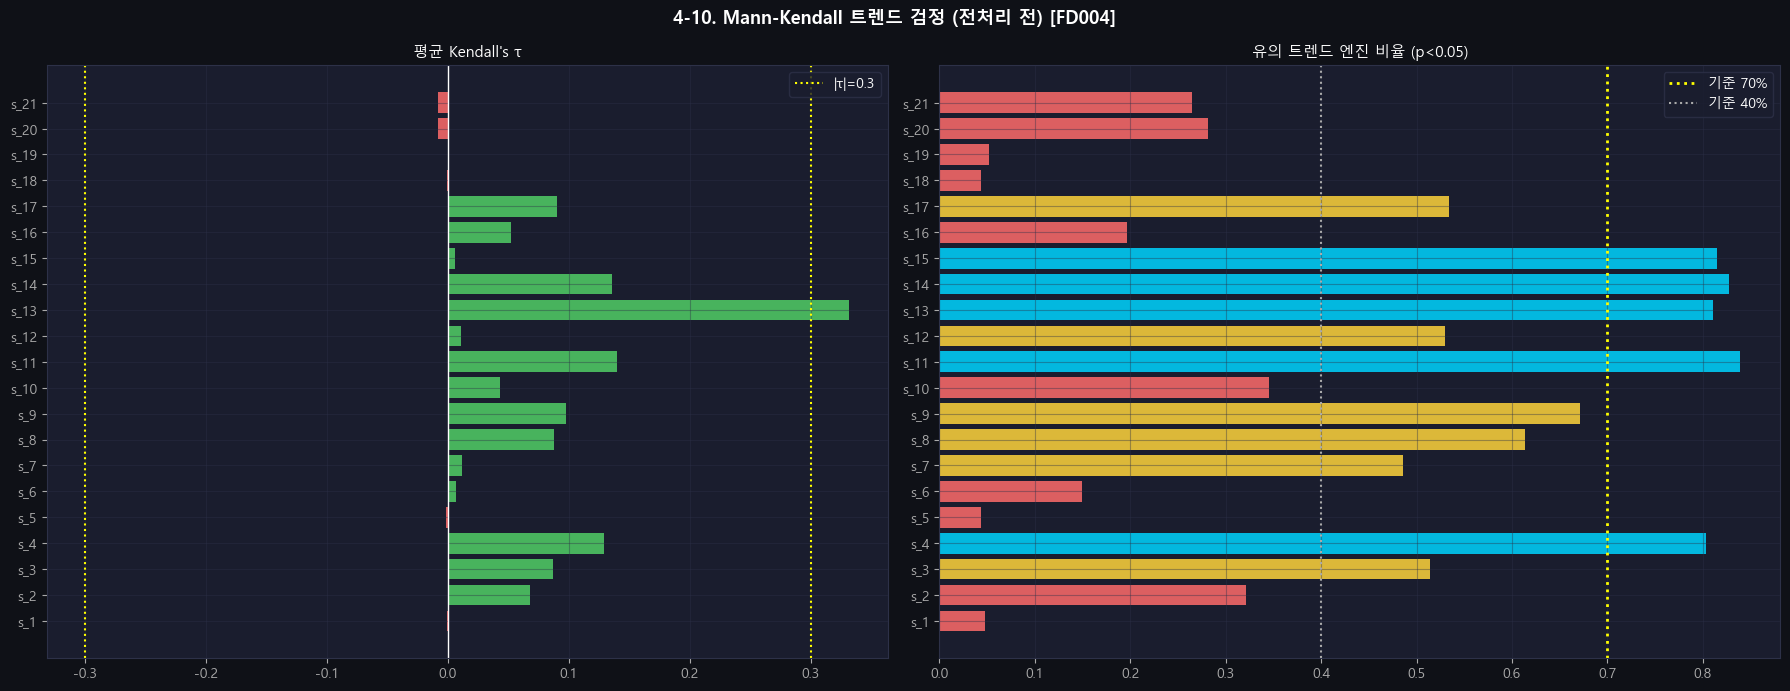

,평균 τ,트렌드 방향,유의 엔진 비율,열화 신호,센서 설명
센서,,,,,
s_1,-0.0009,하강 ↓,4.8%,❌ 약함,T2 팬 입구 온도(°R)
s_2,0.0680,상승 ↑,32.1%,❌ 약함,T24 LPC 출구 온도(°R)
s_3,0.0868,상승 ↑,51.4%,🔶 보통,T30 HPC 출구 온도(°R)
s_4,0.1289,상승 ↑,80.3%,✅ 강함,T50 LPT 출구 온도(°R)
s_5,-0.0013,하강 ↓,4.4%,❌ 약함,P2 팬 입구 압력(psia)
s_6,0.0069,상승 ↑,14.9%,❌ 약함,P15 바이패스 압력(psia)
s_7,0.0113,상승 ↑,48.6%,🔶 보통,P30 HPC 출구 압력(psia)
s_8,0.0876,상승 ↑,61.4%,🔶 보통,Nf 팬 속도(rpm)
s_9,0.0975,상승 ↑,67.1%,🔶 보통,Nc 코어 속도(rpm)


In [23]:
print('=== 4-10. Mann-Kendall 트렌드 검정 (전처리 전) ===')

mk_rows = []
for s in SENSOR_COLS:
    taus, ps = [], []
    for uid in tr_trend['unit_nr'].unique():
        arr = (tr_trend[tr_trend['unit_nr']==uid]
               .sort_values('time_cycles')[s].values)
        if len(arr) >= 8:
            tau, p = kendalltau(np.arange(len(arr)), arr)
            if np.isfinite(tau): taus.append(tau); ps.append(p)
    mean_tau  = np.mean(taus)  if taus else np.nan
    sig_ratio = np.mean([p<0.05 for p in ps]) if ps else np.nan
    mk_rows.append({
        '센서': s, '평균 τ': round(mean_tau,4) if np.isfinite(mean_tau) else np.nan,
        '트렌드 방향': ('상승 ↑' if mean_tau>0 else '하강 ↓') if np.isfinite(mean_tau) else 'N/A',
        '유의 엔진 비율': f'{sig_ratio*100:.1f}%' if np.isfinite(sig_ratio) else 'N/A',
        '열화 신호': ('✅ 강함' if sig_ratio>=0.7 else '🔶 보통' if sig_ratio>=0.4 else '❌ 약함') if np.isfinite(sig_ratio) else '⬜ 상수',
        '센서 설명': SENSOR_DESC.get(s, s)
    })

mk_df = pd.DataFrame(mk_rows).set_index('센서')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('4-10. Mann-Kendall 트렌드 검정 (전처리 전) [FD004]', fontsize=13, fontweight='bold')

tau_vals = [v if np.isfinite(v) else 0 for v in mk_df['평균 τ'].values]
bc_tau   = [C[2] if v>0 else C[1] for v in tau_vals]
axes[0].barh(mk_df.index, tau_vals, color=bc_tau, alpha=0.85)
axes[0].axvline(0, color='white', lw=1)
axes[0].axvline( 0.3, color='yellow', lw=1.5, ls=':')
axes[0].axvline(-0.3, color='yellow', lw=1.5, ls=':', label='|τ|=0.3')
axes[0].set_title("평균 Kendall's τ"); axes[0].legend()

sig_vals = [float(v.replace('%',''))/100 if v!='N/A' else 0 for v in mk_df['유의 엔진 비율'].values]
bc_sig   = [C[0] if v>=0.7 else C[3] if v>=0.4 else C[1] for v in sig_vals]
axes[1].barh(mk_df.index, sig_vals, color=bc_sig, alpha=0.85)
axes[1].axvline(0.7, color='yellow', lw=2, ls=':', label='기준 70%')
axes[1].axvline(0.4, color=GRAY,     lw=1.5, ls=':', label='기준 40%')
axes[1].set_title('유의 트렌드 엔진 비율 (p<0.05)'); axes[1].legend()
plt.tight_layout(); plt.show()
display(mk_df)

### 4-11. 대응 표본 검정 — 초기(RUL 상위 80%) vs 말기(RUL 하위 20%)

=== 4-11. 대응 표본 검정 (전처리 전) ===


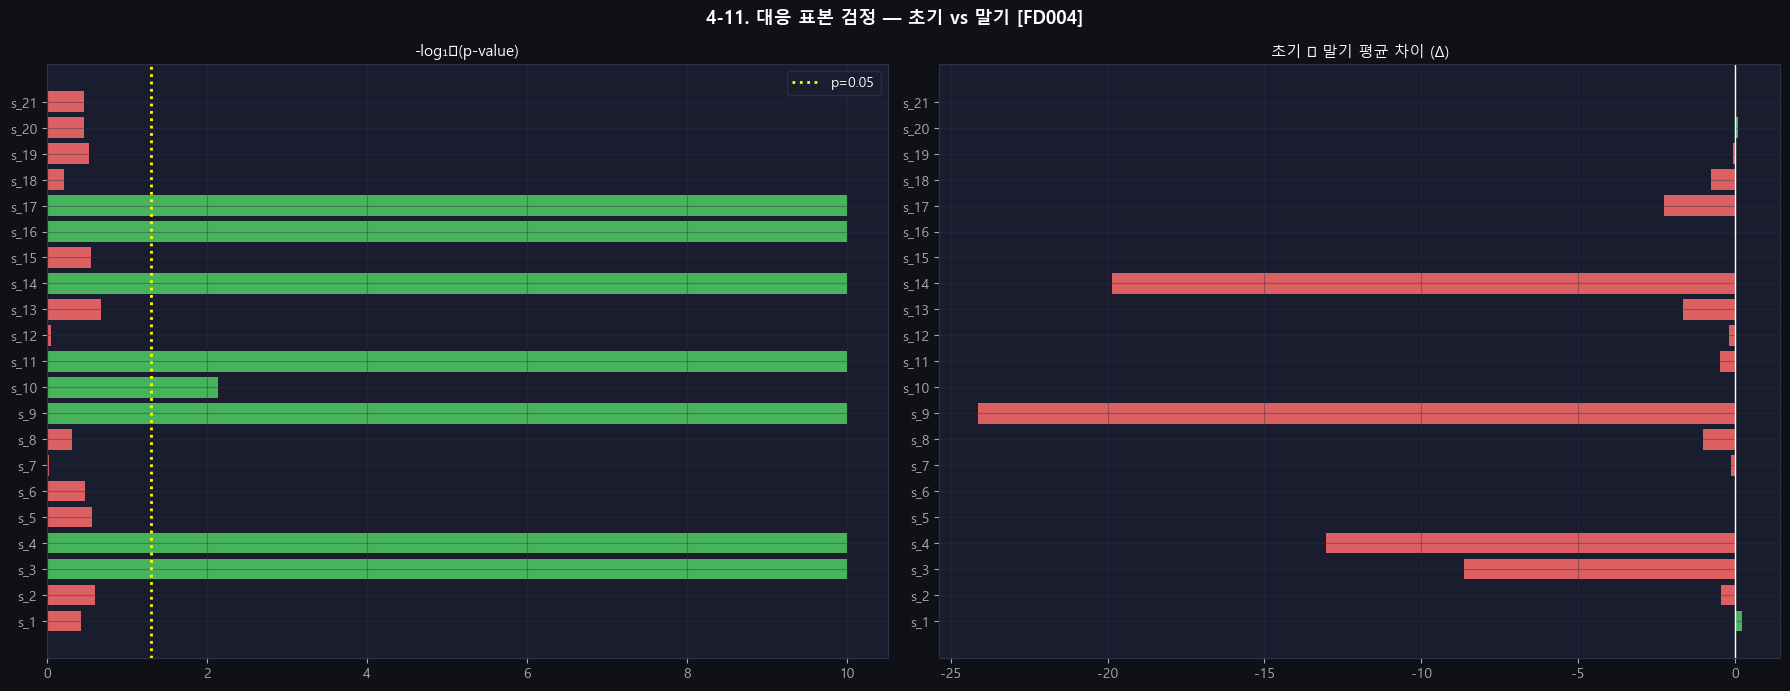

,초기 평균,말기 평균,평균 차이(Δ),검정 방법,p-value,판정,p_adj_BH,판정_BH
센서,,,,,,,,
s_1,472.9264,472.6999,0.2265,Paired t,0.3807,비유의 ⚠️,0.4703,비유의(FDR) ⚠️
s_2,579.3690,579.7918,-0.4228,Paired t,0.2512,비유의 ⚠️,0.4515,비유의(FDR) ⚠️
s_3,1416.5254,1425.1430,-8.6176,Paired t,0.0000,유의 ✅,0.0000,유의(FDR) ✅
s_4,1199.9739,1213.0065,-13.0326,Paired t,0.0000,유의 ✅,0.0000,유의(FDR) ✅
s_5,8.0392,8.0004,0.0387,Paired t,0.2739,비유의 ⚠️,0.4515,비유의(FDR) ⚠️
s_6,11.6013,11.5498,0.0515,Paired t,0.3331,비유의 ⚠️,0.4515,비유의(FDR) ⚠️
s_7,283.1704,283.2796,-0.1092,Paired t,0.9401,비유의 ⚠️,0.9401,비유의(FDR) ⚠️
s_8,2228.4395,2229.4525,-1.0130,Paired t,0.4909,비유의 ⚠️,0.5727,비유의(FDR) ⚠️
s_9,8519.2587,8543.4006,-24.1419,Paired t,0.0000,유의 ✅,0.0000,유의(FDR) ✅



유의한 센서: 8/21개
BH-FDR 보정 후 유의: 8/21개


In [24]:
print('=== 4-11. 대응 표본 검정 (전처리 전) ===')

paired_rows = []
for s in SENSOR_COLS:
    early_means, late_means = [], []
    for uid in tr_trend['unit_nr'].unique():
        udf    = tr_trend[tr_trend['unit_nr']==uid].sort_values('time_cycles')
        thresh = udf['RUL'].quantile(0.20)
        early  = udf[udf['RUL'] >  thresh][s].mean()
        late   = udf[udf['RUL'] <= thresh][s].mean()
        if np.isfinite(early) and np.isfinite(late):
            early_means.append(early); late_means.append(late)
    diffs = np.array(early_means) - np.array(late_means)
    _, p_sw = shapiro(diffs) if len(diffs) >= 3 else (np.nan, 0.0)
    if p_sw > 0.05:
        stat, p_val = ttest_rel(early_means, late_means); test_name = 'Paired t'
    else:
        stat, p_val = wilcoxon(diffs); test_name = 'Wilcoxon'
    paired_rows.append({'센서': s, '초기 평균': round(np.mean(early_means),4),
                        '말기 평균': round(np.mean(late_means),4),
                        '평균 차이(Δ)': round(float(np.mean(diffs)),4),
                        '검정 방법': test_name, 'p-value': round(p_val,4),
                        '판정': '유의 ✅' if p_val<0.05 else '비유의 ⚠️'})

paired_df = pd.DataFrame(paired_rows).set_index('센서')
_pvals = paired_df['p-value'].fillna(1.0).values
_rej, _padj, *_ = multipletests(_pvals, alpha=0.05, method='fdr_bh')
paired_df['p_adj_BH'] = np.round(_padj, 4)
paired_df['판정_BH']  = ['유의(FDR) ✅' if r else '비유의(FDR) ⚠️' for r in _rej]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('4-11. 대응 표본 검정 — 초기 vs 말기 [FD004]', fontsize=13, fontweight='bold')

p_vals = paired_df['p-value'].values
log_p  = -np.log10(np.clip(p_vals, 1e-10, 1))
bc_p   = [C[2] if p<0.05 else C[1] for p in p_vals]
axes[0].barh(paired_df.index, log_p, color=bc_p, alpha=0.85)
axes[0].axvline(-np.log10(0.05), color='yellow', lw=2, ls=':', label='p=0.05')
axes[0].set_title('-log₁₀(p-value)'); axes[0].legend()

diff_vals = paired_df['평균 차이(Δ)'].values
bc_d = [C[2] if v>0 else C[1] for v in diff_vals]
axes[1].barh(paired_df.index, diff_vals, color=bc_d, alpha=0.85)
axes[1].axvline(0, color='white', lw=1)
axes[1].set_title('초기 − 말기 평균 차이 (Δ)')
plt.tight_layout(); plt.show()

display(paired_df)
print(f"\n유의한 센서: {(paired_df['판정']=='유의 ✅').sum()}/{len(paired_df)}개")
print(f"BH-FDR 보정 후 유의: {sum(_rej)}/{len(paired_df)}개")

---
## 5. RUL 파생 & 클러스터별 Gaussian 필터

=== 5. RUL Cap & 클러스터별 Gaussian ===


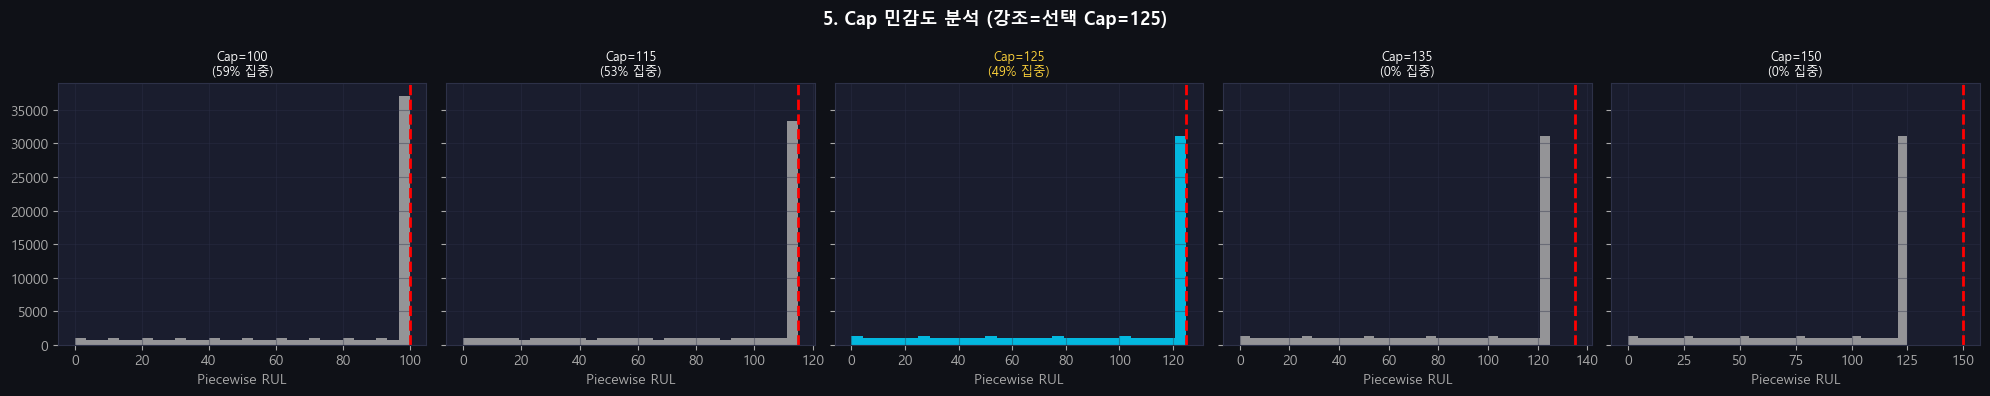

✅ 클러스터별 Gaussian 필터링 완료 (σ=2)
   RUL: min=0  max=125  Cap=125


In [25]:
print('=== 5. RUL Cap & 클러스터별 Gaussian ===')

max_cycle = train_s1.groupby('unit_nr')['time_cycles'].max().rename('max_cycle')
train_s1 = train_s1.join(max_cycle, on='unit_nr')
train_s1['RUL'] = (train_s1['max_cycle'] - train_s1['time_cycles']).clip(upper=RUL_CAP)
train_s1.drop(columns=['max_cycle'], inplace=True)

# Cap 민감도 분석
caps = [100, 115, 125, 135, 150]
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
fig.suptitle('5. Cap 민감도 분석 (강조=선택 Cap=125)', fontsize=13, fontweight='bold')
for ax, cap in zip(axes, caps):
    tmp = train_s1['RUL'].clip(upper=cap)
    pct = (train_s1['RUL']>=cap).mean()*100
    ax.hist(tmp, bins=30, color=C[0] if cap==RUL_CAP else GRAY, alpha=0.85, edgecolor='none')
    ax.axvline(cap, color='red', ls='--', lw=2)
    ax.set_title(f'Cap={cap}\n({pct:.0f}% 집중)',
                 color='#ffd43b' if cap==RUL_CAP else WHITE, fontsize=9)
    ax.set_xlabel('Piecewise RUL')
plt.tight_layout(); plt.show()

# 클러스터별 Gaussian
train_s2 = train_s1.copy(); test_s2 = test_s1.copy()
for c in range(N_CLUSTERS):
    for uid in train_s1[train_s1['op_cluster']==c]['unit_nr'].unique():
        mask = train_s2['unit_nr']==uid
        for s in USEFUL_SENSORS:
            train_s2.loc[mask,s] = gaussian_filter1d(train_s2.loc[mask,s].values, sigma=GAUSS_SIGMA)
    for uid in test_s1[test_s1['op_cluster']==c]['unit_nr'].unique():
        mask = test_s2['unit_nr']==uid
        for s in USEFUL_SENSORS:
            test_s2.loc[mask,s] = gaussian_filter1d(test_s2.loc[mask,s].values, sigma=GAUSS_SIGMA)

print(f'✅ 클러스터별 Gaussian 필터링 완료 (σ={GAUSS_SIGMA})')
print(f'   RUL: min={train_s1["RUL"].min()}  max={train_s1["RUL"].max()}  Cap={RUL_CAP}')

## 6. Validation 분리 & 클러스터별 MinMax 정규화

In [26]:
print('=== 6. Validation 분리 & 클러스터별 정규화 ===')

all_units = sorted(train_s2['unit_nr'].unique())
train_units, valid_units = train_test_split(all_units, test_size=0.2, random_state=42)
subtrain_raw = train_s2[train_s2['unit_nr'].isin(train_units)].copy()
valid_raw    = train_s2[train_s2['unit_nr'].isin(valid_units)].copy()
print(f'Sub-train: {len(train_units)}대 | Validation: {len(valid_units)}대')

# 클러스터별 MinMax
scalers = {}
train_s4 = subtrain_raw.copy()
valid_s4 = valid_raw.copy()
test_s4  = test_s2.copy()

for c in range(N_CLUSTERS):
    mask_tr = train_s4['op_cluster']==c
    mask_va = valid_s4['op_cluster']==c
    mask_te = test_s4['op_cluster']==c
    sc = MinMaxScaler()
    train_s4.loc[mask_tr, USEFUL_SENSORS] = sc.fit_transform(train_s4.loc[mask_tr, USEFUL_SENSORS])
    if mask_va.any():
        valid_s4.loc[mask_va, USEFUL_SENSORS] = sc.transform(valid_s4.loc[mask_va, USEFUL_SENSORS])
    if mask_te.any():
        test_s4.loc[mask_te, USEFUL_SENSORS]  = sc.transform(test_s4.loc[mask_te, USEFUL_SENSORS])
    scalers[c] = sc
    print(f'  클러스터 {c}: {mask_tr.sum()}행 기준 fit')

# OHE
for df in [train_s4, valid_s4, test_s4]:
    ohe = pd.get_dummies(df['op_cluster'], prefix='cluster', dtype=float)
    for col in ohe.columns:
        df[col] = ohe[col].values

print('✅ 클러스터별 MinMax + OHE 완료')
OHE_COLS = [c for c in train_s4.columns if c.startswith('cluster_')]
subtrain_s4 = train_s4  # 전처리 후 검증에서 참조용

=== 6. Validation 분리 & 클러스터별 정규화 ===
Sub-train: 199대 | Validation: 50대
  클러스터 0: 12409행 기준 fit
  클러스터 1: 7385행 기준 fit
  클러스터 2: 7371행 기준 fit
  클러스터 3: 7307행 기준 fit
  클러스터 4: 7447행 기준 fit
  클러스터 5: 7375행 기준 fit
✅ 클러스터별 MinMax + OHE 완료


## 7. ML 파생변수 생성 (엔진×클러스터 단위)

In [27]:
print('=== 7. ML 파생변수 (엔진×클러스터 단위) ===')

def add_temporal_features_clustered(df, sensor_cols, lags, diffs, rolls, roll_stds, emas):
    df = df.copy().sort_values(['unit_nr','time_cycles'])
    for s in sensor_cols:
        for uid in df['unit_nr'].unique():
            mask_uid = df['unit_nr']==uid
            uid_df = df[mask_uid].copy()
            for c in range(N_CLUSTERS):
                mask_c = uid_df['op_cluster']==c
                if mask_c.sum() < 2: continue
                idx = uid_df[mask_c].index
                vals = uid_df.loc[idx, s]
                for lag in lags:
                    df.loc[idx, f'{s}_lag{lag}'] = vals.shift(lag).values
                for d in diffs:
                    df.loc[idx, f'{s}_diff{d}'] = vals.diff(d).values
                for r in rolls:
                    df.loc[idx, f'{s}_roll{r}'] = vals.rolling(r, min_periods=1).mean().values
                for r in roll_stds:
                    df.loc[idx, f'{s}_std{r}']  = vals.rolling(r, min_periods=1).std().fillna(0).values
                for e in emas:
                    df.loc[idx, f'{s}_ema{e}']  = vals.ewm(span=e, adjust=False).mean().values
    return df.fillna(0)

subtrain_ml = add_temporal_features_clustered(train_s4, USEFUL_SENSORS, [1,3,5],[1],[3,5],[3,5],[5])
valid_ml    = add_temporal_features_clustered(valid_s4,  USEFUL_SENSORS, [1,3,5],[1],[3,5],[3,5],[5])
test_ml     = add_temporal_features_clustered(test_s4,   USEFUL_SENSORS, [1,3,5],[1],[3,5],[3,5],[5])

ML_FEATURES = [c for c in subtrain_ml.columns
               if c not in ID_COLS + OP_COLS + ['RUL','op_cluster']]
print(f'ML 피처 수: {len(ML_FEATURES)}개 (OHE 포함)')

=== 7. ML 파생변수 (엔진×클러스터 단위) ===
ML 피처 수: 156개 (OHE 포함)


## 8. DL 슬라이딩 윈도우

In [28]:
print('=== 8. DL 슬라이딩 윈도우 ===')
DL_FEATURES = USEFUL_SENSORS + OHE_COLS

def sliding_window_long(df, sensor_cols, window_size, step, has_rul=True):
    records = []; sample_id = 0
    for uid in df['unit_nr'].unique():
        udf = df[df['unit_nr']==uid].sort_values('time_cycles').reset_index(drop=True)
        n   = len(udf)
        starts = range(0, n-window_size+1, step) if has_rul else [max(0, n-window_size)]
        for start in starts:
            end = start + window_size
            seg = udf.iloc[start:end]
            pad_len = window_size - len(seg)
            for ts, row in enumerate(seg.itertuples(index=False)):
                rec = {'sample_id': sample_id, 'timestep': ts+pad_len}
                for s in sensor_cols:
                    rec[s] = getattr(row, s) if hasattr(row, s) else 0.0
                rec['RUL'] = udf['RUL'].iloc[min(end-1,n-1)] if has_rul else 0.0
                records.append(rec)
            if pad_len > 0:
                for ts in range(pad_len):
                    rec = {'sample_id': sample_id, 'timestep': ts}
                    for s in sensor_cols: rec[s] = 0.0
                    rec['RUL'] = udf['RUL'].iloc[0] if has_rul else 0.0
                    records.append(rec)
            sample_id += 1
    return pd.DataFrame(records)

dl_subtrain_long = sliding_window_long(train_s4, DL_FEATURES, WINDOW_SIZE, STEP, True)
dl_valid_long    = sliding_window_long(valid_s4,  DL_FEATURES, WINDOW_SIZE, STEP, True)
dl_test_long     = sliding_window_long(test_s4,   DL_FEATURES, WINDOW_SIZE, STEP, False)

n_sub = dl_subtrain_long['sample_id'].nunique()
n_val = dl_valid_long['sample_id'].nunique()
n_te  = dl_test_long['sample_id'].nunique()
print(f'Sub-train: {n_sub}샘플 | Valid: {n_val}샘플 | Test: {n_te}샘플')
print(f'DL 피처 수: {len(DL_FEATURES)}개 (USEFUL_SENSORS + OHE)')

=== 8. DL 슬라이딩 윈도우 ===
Sub-train: 43523샘플 | Valid: 10505샘플 | Test: 248샘플
DL 피처 수: 21개 (USEFUL_SENSORS + OHE)


---
## 9. 전처리 후 검증

### 9-1. 센서 상관관계 전후 비교 (21개 → 유용 센서)

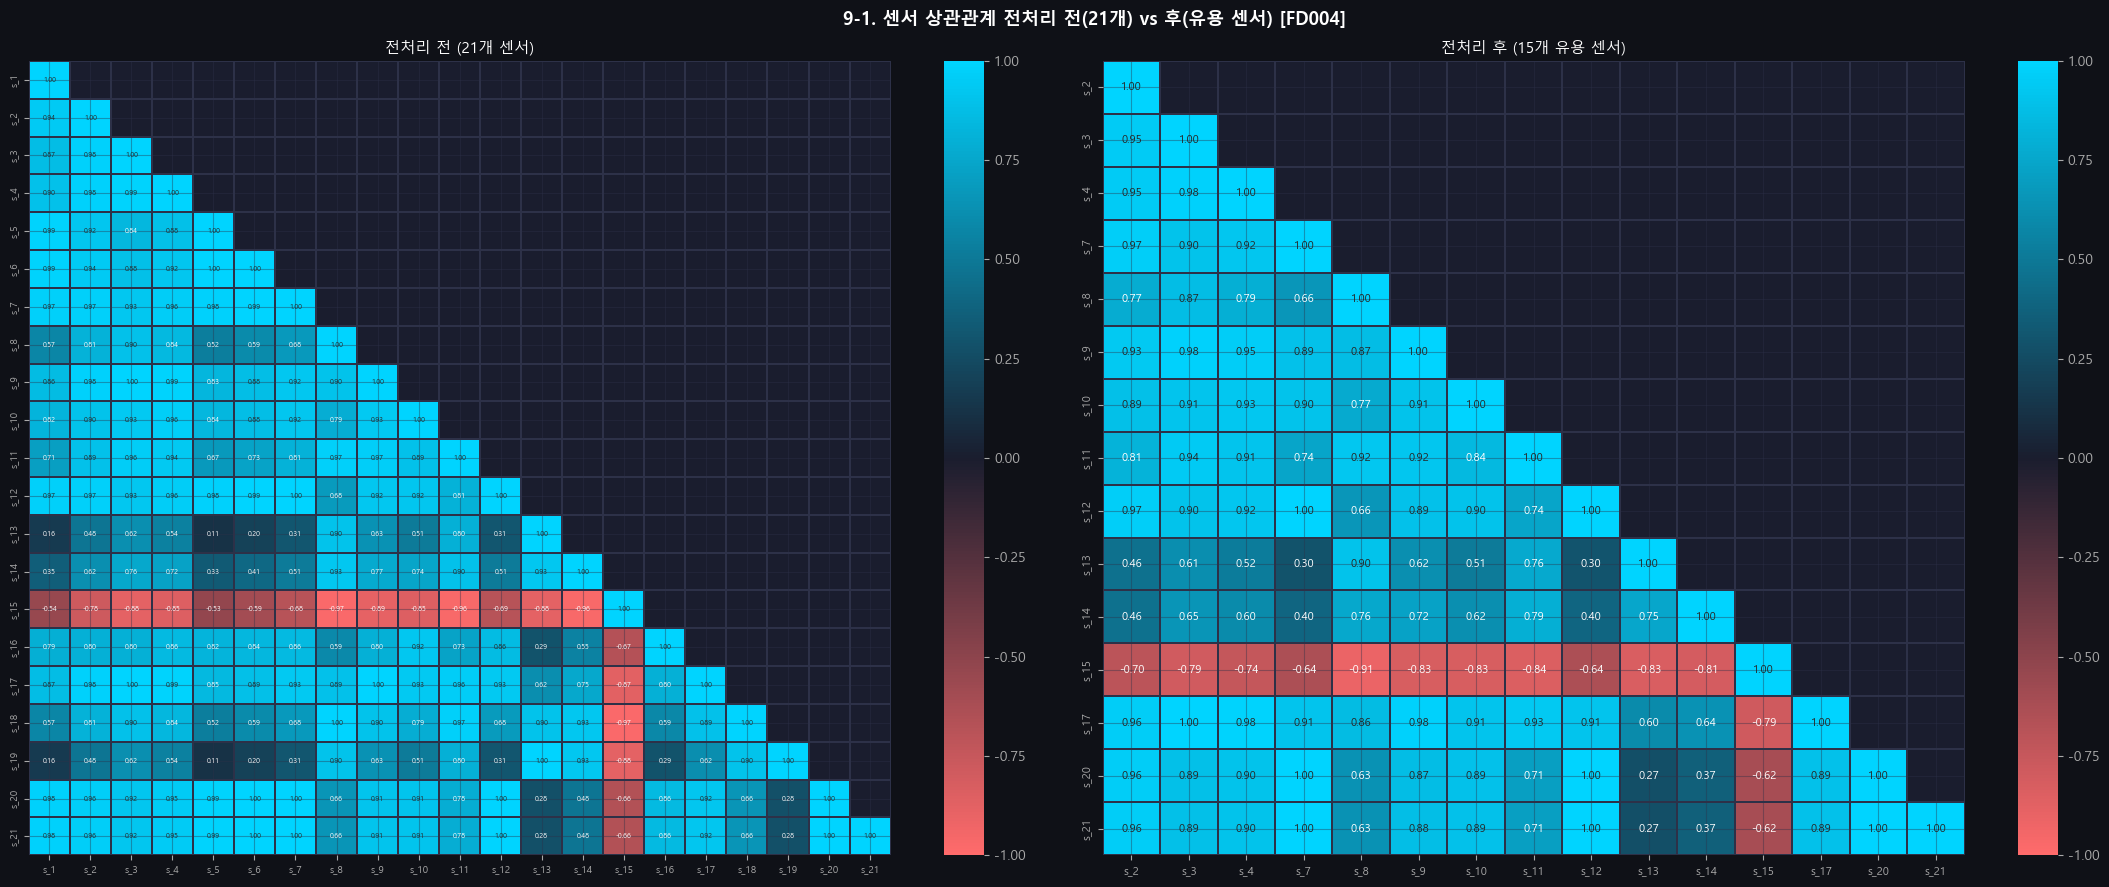

고상관 쌍(|r|>0.9): 전처리 전 87개 → 후 41개


In [29]:
corr_after = subtrain_s4[USEFUL_SENSORS].corr()

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle('9-1. 센서 상관관계 전처리 전(21개) vs 후(유용 센서) [FD004]',
             fontsize=13, fontweight='bold')

mask_b = np.triu(np.ones_like(corr_before, dtype=bool), k=1)
sns.heatmap(corr_before, ax=axes[0], mask=mask_b, cmap=cmap_rg, center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size': 5}, linewidths=0.3, linecolor=GRID)
axes[0].set_title(f'전처리 전 (21개 센서)', fontsize=11)
axes[0].tick_params(labelsize=7)

mask_a = np.triu(np.ones_like(corr_after, dtype=bool), k=1)
sns.heatmap(corr_after, ax=axes[1], mask=mask_a, cmap=cmap_rg, center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size': 8}, linewidths=0.3, linecolor=GRID)
axes[1].set_title(f'전처리 후 ({len(USEFUL_SENSORS)}개 유용 센서)', fontsize=11)
axes[1].tick_params(labelsize=8)
plt.tight_layout(); plt.show()

pairs_after = [(USEFUL_SENSORS[i], USEFUL_SENSORS[j], round(corr_after.iloc[i,j],3))
               for i in range(len(USEFUL_SENSORS)) for j in range(i+1, len(USEFUL_SENSORS))
               if abs(corr_after.iloc[i,j]) > 0.9]
print(f'고상관 쌍(|r|>0.9): 전처리 전 {len(pairs)}개 → 후 {len(pairs_after)}개')

### 9-2. 센서 분포 전처리 전후 비교 (원본 → 스무딩 → 정규화)

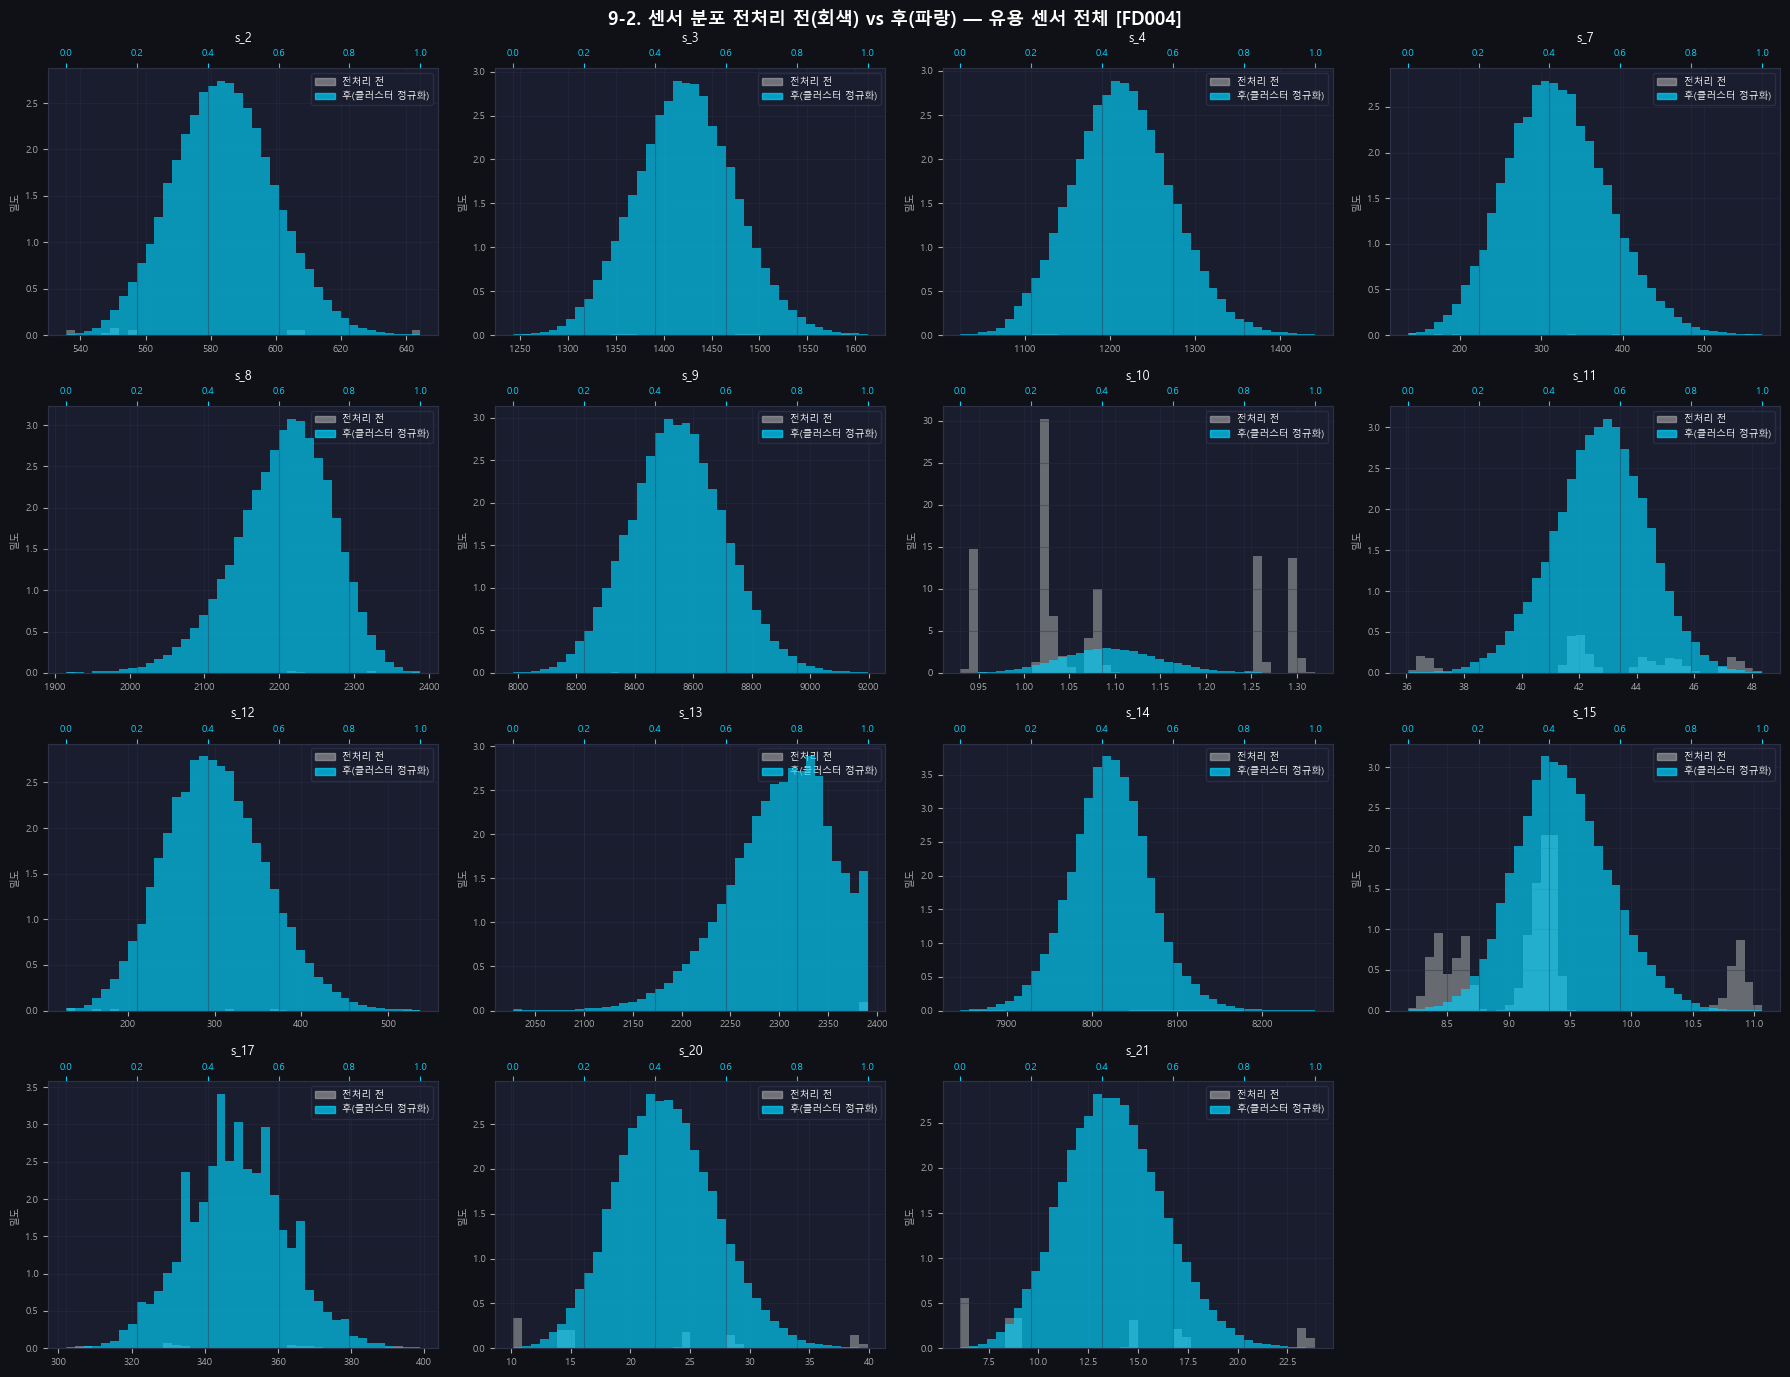

📌 회색=원본 스케일  파랑=클러스터별 MinMax 정규화 후(0~1 범위)
📌 FD004: 6조건 혼재로 다봉 분포 → 클러스터별 정규화 후 균일 분포


In [30]:
n_c = 4; n_r = (len(USEFUL_SENSORS) + n_c - 1) // n_c
fig, axes = plt.subplots(n_r, n_c, figsize=(18, n_r * 3.5))
fig.suptitle('9-2. 센서 분포 전처리 전(회색) vs 후(파랑) — 유용 센서 전체 [FD004]',
             fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, USEFUL_SENSORS):
    before_data = train_raw[s]
    after_data  = subtrain_s4[s]
    ax2 = ax.twiny()
    ax.hist(before_data,  bins=40, color=GRAY, alpha=0.55, density=True, edgecolor='none')
    ax2.hist(after_data,  bins=40, color=C[0], alpha=0.65, density=True, edgecolor='none')
    ax.set_title(f'{s}', fontsize=9)
    ax.set_ylabel('밀도', fontsize=7)
    ax.tick_params(labelsize=7); ax2.tick_params(labelsize=7, colors=C[0])
    handles = [mpatches.Patch(color=GRAY, alpha=0.6, label='전처리 전'),
               mpatches.Patch(color=C[0], alpha=0.7, label='후(클러스터 정규화)')]
    ax.legend(handles=handles, fontsize=7, loc='upper right')

for ax in axes.flat[len(USEFUL_SENSORS):]: ax.set_visible(False)
plt.tight_layout(); plt.show()
print('📌 회색=원본 스케일  파랑=클러스터별 MinMax 정규화 후(0~1 범위)')
print('📌 FD004: 6조건 혼재로 다봉 분포 → 클러스터별 정규화 후 균일 분포')

### 9-3. Train vs Test 분포 비교 (전처리 후, KS 검정)

=== 9-3. Train vs Test 분포 비교 (KS 검정) ===


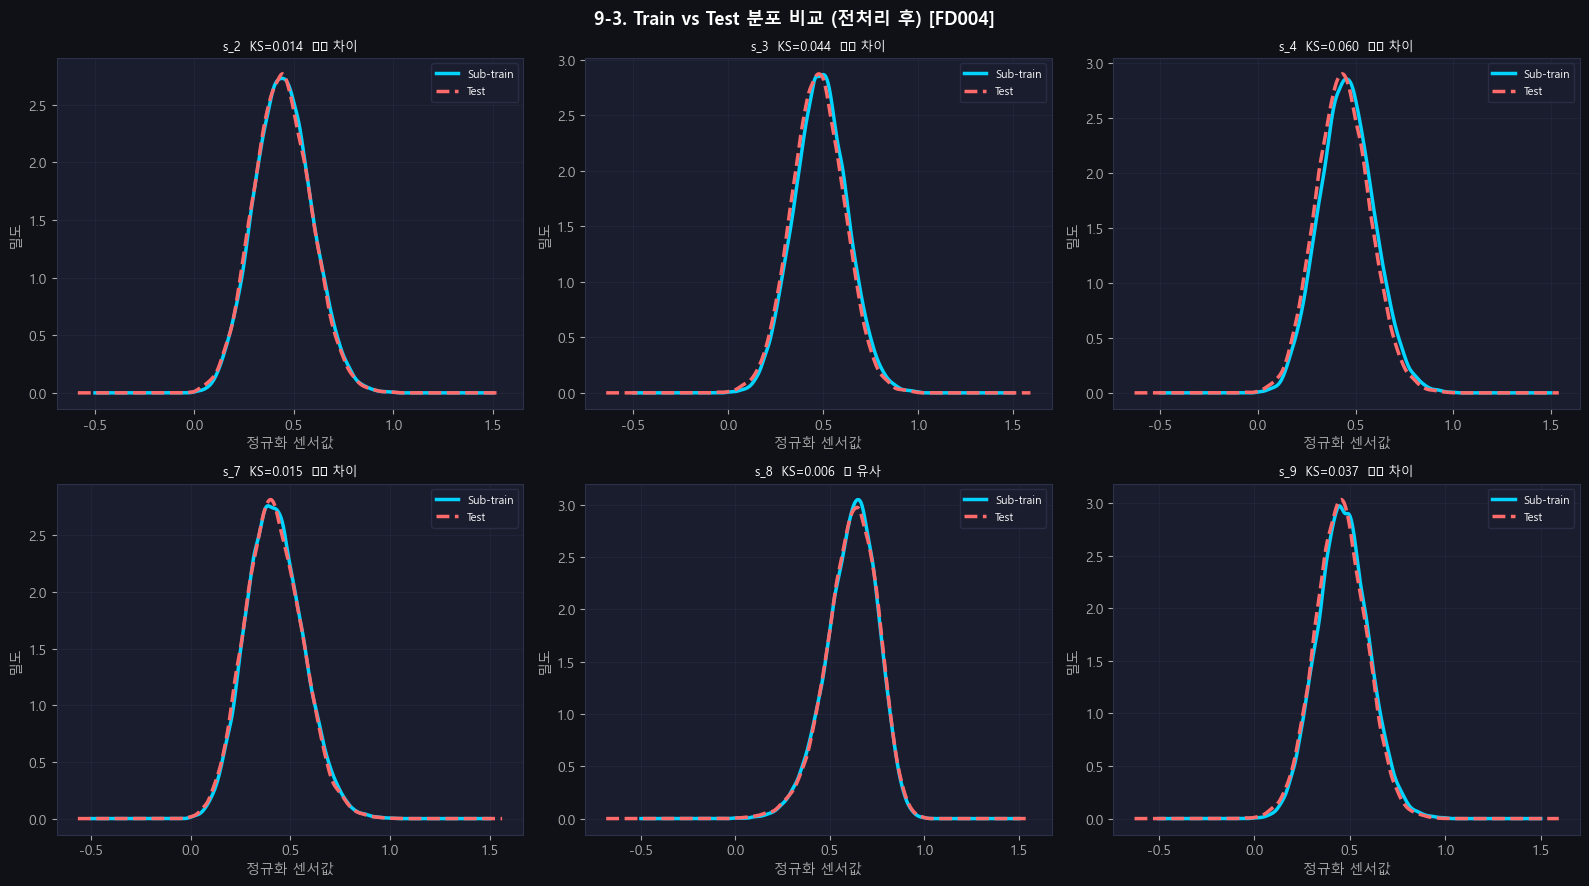


[전체 유용 센서 KS + BH-FDR 보정]


,KS,p,p_adj_BH,판정_BH
센서,,,,
s_2,0.0144,0.0002,0.0003,차이(FDR) ⚠️
s_3,0.0443,0.0000,0.0000,차이(FDR) ⚠️
s_4,0.0601,0.0000,0.0000,차이(FDR) ⚠️
s_7,0.0150,0.0001,0.0002,차이(FDR) ⚠️
s_8,0.0064,0.3074,0.3074,유사(FDR) ✅
s_9,0.0369,0.0000,0.0000,차이(FDR) ⚠️
s_10,0.0250,0.0000,0.0000,차이(FDR) ⚠️
s_11,0.0650,0.0000,0.0000,차이(FDR) ⚠️
s_12,0.0153,0.0001,0.0002,차이(FDR) ⚠️


In [31]:
print('=== 9-3. Train vs Test 분포 비교 (KS 검정) ===')
show6 = USEFUL_SENSORS[:6]; ks_rows = []
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('9-3. Train vs Test 분포 비교 (전처리 후) [FD004]', fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, show6):
    tr_v = subtrain_s4[s].dropna(); te_v = test_s4[s].dropna()
    try: tr_v.plot.kde(ax=ax, color=C[0], lw=2.5, label='Sub-train')
    except: pass
    try: te_v.plot.kde(ax=ax, color=C[1], lw=2.5, ls='--', label='Test')
    except: pass
    ks_stat, ks_p = ks_2samp(tr_v, te_v)
    verdict = '✅ 유사' if ks_p>0.05 else '⚠️ 차이'
    ks_rows.append({'센서': s, 'KS통계량': round(ks_stat,4), 'p-value': round(ks_p,4), '판정': verdict})
    ax.set_title(f'{s}  KS={ks_stat:.3f}  {verdict}', fontsize=9)
    ax.set_xlabel('정규화 센서값'); ax.set_ylabel('밀도'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# 전체 센서 KS + BH-FDR
_all_ks = []
for s in USEFUL_SENSORS:
    _ks, _kp = ks_2samp(subtrain_s4[s].dropna(), test_s4[s].dropna())
    _all_ks.append({'센서': s, 'KS': round(_ks,4), 'p': round(_kp,4)})
_ks_full = pd.DataFrame(_all_ks).set_index('센서')
_rej2, _padj2, *_ = multipletests(_ks_full['p'].values, alpha=0.05, method='fdr_bh')
_ks_full['p_adj_BH'] = np.round(_padj2, 4)
_ks_full['판정_BH']  = ['차이(FDR) ⚠️' if r else '유사(FDR) ✅' for r in _rej2]
print('\n[전체 유용 센서 KS + BH-FDR 보정]')
display(_ks_full)

### 9-4. 클러스터별 RUL 상관계수 전후 비교

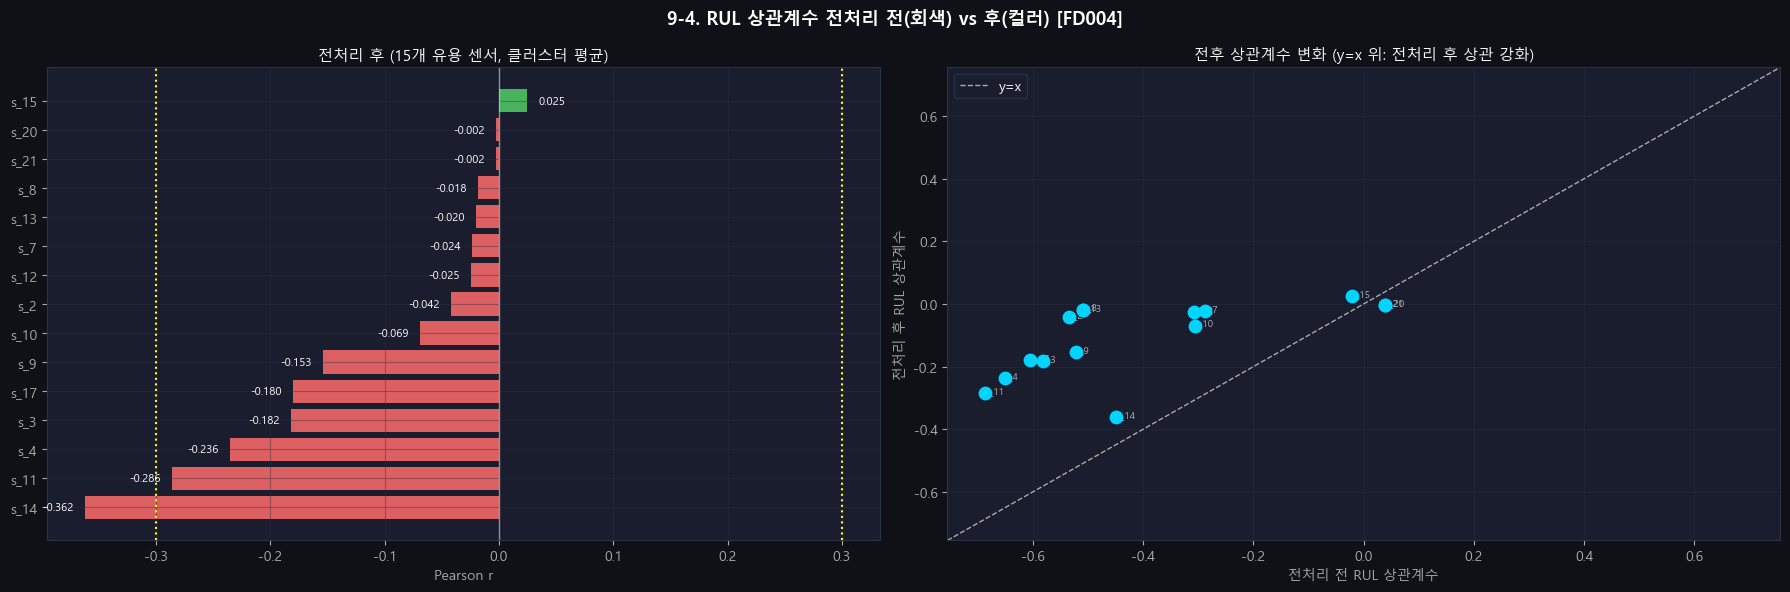

In [32]:
cluster_rul_corrs_after = []
for c in range(N_CLUSTERS):
    mask = subtrain_s4['op_cluster'] == c
    sub  = subtrain_s4[mask]
    if len(sub) > 10 and 'RUL' in sub.columns:
        corr_c = sub[USEFUL_SENSORS + ['RUL']].corr()['RUL'][USEFUL_SENSORS]
        cluster_rul_corrs_after.append(corr_c)

rul_corr_after = pd.concat(cluster_rul_corrs_after, axis=1).mean(axis=1).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('9-4. RUL 상관계수 전처리 전(회색) vs 후(컬러) [FD004]',
             fontsize=13, fontweight='bold')

bc = [C[1] if v<0 else C[2] for v in rul_corr_after]
bars = axes[0].barh(rul_corr_after.index, rul_corr_after.values, color=bc, alpha=0.85)
axes[0].axvline(0, color='white', lw=1, alpha=0.5)
axes[0].axvline( 0.3, color='yellow', lw=1.5, ls=':')
axes[0].axvline(-0.3, color='yellow', lw=1.5, ls=':')
axes[0].set_title(f'전처리 후 ({len(USEFUL_SENSORS)}개 유용 센서, 클러스터 평균)')
axes[0].set_xlabel('Pearson r')
for bar, val in zip(bars, rul_corr_after.values):
    axes[0].text(val+(0.01 if val>=0 else -0.01), bar.get_y()+bar.get_height()/2,
                 f'{val:.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=8)

common_s = [s for s in USEFUL_SENSORS if s in rul_corr_before.index]
r_b = rul_corr_before[common_s]; r_a = rul_corr_after[common_s]
axes[1].scatter(r_b, r_a, color=C[0], s=80, zorder=5)
for s in common_s:
    axes[1].annotate(s, (r_b[s], r_a[s]), fontsize=7, color=GRAY)
lim = max(abs(r_b).max(), abs(r_a).max()) * 1.1
axes[1].set_xlim(-lim, lim); axes[1].set_ylim(-lim, lim)
axes[1].plot([-lim,lim], [-lim,lim], color=GRAY, lw=1, ls='--', label='y=x')
axes[1].set_xlabel('전처리 전 RUL 상관계수'); axes[1].set_ylabel('전처리 후 RUL 상관계수')
axes[1].set_title('전후 상관계수 변화 (y=x 위: 전처리 후 상관 강화)')
axes[1].legend()
plt.tight_layout(); plt.show()

### 9-5. ML 파생변수 다중공선성 검증 (|r| > 0.95)

In [33]:
print('=== 9-5. ML 파생변수 다중공선성 검증 ===')

_feat_check = [f for f in ML_FEATURES if not f.startswith('cluster_')]
ml_corr = subtrain_ml[_feat_check].corr().abs()
high_pairs = []
for i in range(len(_feat_check)):
    for j in range(i+1, len(_feat_check)):
        if ml_corr.iloc[i,j] > 0.95:
            high_pairs.append({'피처A': _feat_check[i], '피처B': _feat_check[j],
                                '|r|': round(ml_corr.iloc[i,j],3)})

if high_pairs:
    hp_df = pd.DataFrame(high_pairs).sort_values('|r|', ascending=False)
    print(f'|r|>0.95 고상관 ML 피처 쌍: {len(hp_df)}개')
    display(hp_df.head(20))
else:
    print('✅ |r|>0.95 고상관 쌍 없음')

print(f'\nML 총 피처 수: {len(ML_FEATURES)}개')
print('📌 파생변수(lag/roll/ema) 간 고상관은 모델 훈련 시 정규화로 처리 가능')

=== 9-5. ML 파생변수 다중공선성 검증 ===
|r|>0.95 고상관 ML 피처 쌍: 287개


,피처A,피처B,|r|
284,s_20_ema5,s_21_ema5,1.0
281,s_20_std5,s_21_std5,1.0
280,s_20_std3,s_21_std3,1.0
278,s_20_roll5,s_21_roll5,1.0
183,s_7_ema5,s_12_ema5,1.0
178,s_7_std5,s_12_std5,1.0
175,s_7_std3,s_12_std3,1.0
169,s_7_roll5,s_12_roll5,1.0
154,s_7_lag5,s_12_lag5,1.0
149,s_7_lag3,s_12_lag3,1.0



ML 총 피처 수: 156개
📌 파생변수(lag/roll/ema) 간 고상관은 모델 훈련 시 정규화로 처리 가능


---
## 10. CSV 저장 & 최종 요약

In [34]:
OUTPUT_DIR = 'preprocessed_FD004'
os.makedirs(OUTPUT_DIR, exist_ok=True)
dl_dir = os.path.join(OUTPUT_DIR, 'dl')
os.makedirs(dl_dir, exist_ok=True)

# ── 파일 경로 정의 ─────────────────────────────────────────────────────────
ml_subtrain_path  = os.path.join(OUTPUT_DIR, 'FD004_ml_subtrain.csv')
ml_valid_path     = os.path.join(OUTPUT_DIR, 'FD004_ml_valid.csv')
ml_test_path      = os.path.join(OUTPUT_DIR, 'FD004_ml_test.csv')
ml_test_eval_path = os.path.join(OUTPUT_DIR, 'FD004_ml_test_eval.csv')
dl_subtrain_path  = os.path.join(dl_dir, 'FD004_dl_subtrain_long.csv')
dl_valid_path     = os.path.join(dl_dir, 'FD004_dl_valid_long.csv')
dl_test_path      = os.path.join(dl_dir, 'FD004_dl_test_long.csv')
rul_path          = os.path.join(OUTPUT_DIR, 'FD004_test_RUL.csv')
scaler_path       = os.path.join(OUTPUT_DIR, 'FD004_scalers_by_cluster.pkl')
ml_feat_path      = os.path.join(OUTPUT_DIR, 'FD004_ml_features.txt')
dl_feat_path      = os.path.join(OUTPUT_DIR, 'FD004_dl_features.txt')
kmeans_path       = os.path.join(OUTPUT_DIR, 'FD004_kmeans.pkl')
op_scaler_path    = os.path.join(OUTPUT_DIR, 'FD004_op_scaler.pkl')
ml_val_eval_path  = os.path.join(OUTPUT_DIR, 'FD004_ml_val_eval.csv')
dl_val_eval_path  = os.path.join(dl_dir,     'FD004_dl_val_eval_long.csv')

# ── val_eval 데이터 생성 (수명 50~90% 랜덤 절단, seed=42) ────────────────
# 기존 문제: val_eval이 마지막 타임스텝(RUL≈0) 사용 → 모델이 0만 예측해도 RMSE≈0
# 해결: 수명 50~90% 지점 랜덤 절단 → test와 유사한 평가 환경 구성
print('=== val_eval 생성 (수명 50~90% 절단, seed=42) ===')

OHE_COLS_VE = [f'cluster_{i}' for i in range(N_CLUSTERS)]
for _col in OHE_COLS_VE:
    if _col not in valid_s4.columns:
        _ohe = pd.get_dummies(valid_s4['op_cluster'], prefix='cluster', dtype=float)
        for _c in OHE_COLS_VE:
            valid_s4[_c] = _ohe[_c].values if _c in _ohe.columns else 0.0
        break

rng = np.random.RandomState(42)
ml_val_eval_rows, dl_val_eval_X, dl_val_eval_y = [], [], []

for uid in np.sort(valid_s4['unit_nr'].unique()):
    udf      = valid_s4[valid_s4['unit_nr']==uid].sort_values('time_cycles').reset_index(drop=True)
    n        = len(udf)
    cut_idx  = max(WINDOW_SIZE, min(int(n * rng.uniform(0.5, 0.9)), n))
    cut_time = udf.iloc[cut_idx-1]['time_cycles']
    ml_uid   = valid_ml[valid_ml['unit_nr']==uid].sort_values('time_cycles').reset_index(drop=True)
    ml_match = ml_uid[ml_uid['time_cycles']==cut_time]
    if len(ml_match) > 0:
        ml_val_eval_rows.append(ml_match.iloc[0].copy())
    else:
        ml_val_eval_rows.append(ml_uid.iloc[min(cut_idx-1, len(ml_uid)-1)].copy())
    _avail = [f for f in DL_FEATURES if f in udf.columns]
    data   = udf[_avail].values.astype(np.float32)
    window = data[max(0, cut_idx-WINDOW_SIZE):cut_idx]
    if len(window) < WINDOW_SIZE:
        pad    = np.zeros((WINDOW_SIZE-len(window), len(_avail)), dtype=np.float32)
        window = np.vstack([pad, window])
    dl_val_eval_X.append(window)
    dl_val_eval_y.append(float(udf['RUL'].iloc[cut_idx-1]))

val_eval_ml = pd.DataFrame(ml_val_eval_rows).reset_index(drop=True)
X_ve = np.array(dl_val_eval_X, dtype=np.float32)
y_ve = np.array(dl_val_eval_y, dtype=np.float32)

_dl_feats_ve = [f for f in DL_FEATURES if f in valid_s4.columns]
rows_ve = []
for sid in range(len(X_ve)):
    for t in range(WINDOW_SIZE):
        row = {'sample_id': sid, 'timestep': t}
        for fi, fname in enumerate(_dl_feats_ve): row[fname] = float(X_ve[sid, t, fi])
        row['RUL'] = float(y_ve[sid])
        rows_ve.append(row)
dl_val_eval_long = pd.DataFrame(rows_ve)

old_rul = np.array([
    float(valid_s4[valid_s4['unit_nr']==uid].sort_values('time_cycles')['RUL'].iloc[-1])
    for uid in np.sort(valid_s4['unit_nr'].unique())])
print(f'  기존 val_eval RUL 평균: {old_rul.mean():.1f} (≈0에 가까움 → 부적절)')
print(f'  개선 val_eval RUL 평균: {y_ve.mean():.1f}  (test 분포와 유사)')
print(f'  ML shape: {val_eval_ml.shape} | DL shape: {dl_val_eval_long.shape}')

# ── ML CSV 저장 ───────────────────────────────────────────────────────────
test_last_ml = (test_ml.sort_values(['unit_nr','time_cycles'])
                .groupby('unit_nr', as_index=False).last().reset_index(drop=True))
test_last_ml['RUL'] = rul_df['RUL'].values

subtrain_ml.to_csv(ml_subtrain_path,   index=False, encoding='utf-8-sig')
valid_ml.to_csv(ml_valid_path,         index=False, encoding='utf-8-sig')
test_ml.to_csv(ml_test_path,           index=False, encoding='utf-8-sig')
rul_df.to_csv(rul_path,                index=False, encoding='utf-8-sig')
test_last_ml.to_csv(ml_test_eval_path, index=False, encoding='utf-8-sig')

# ── DL Long Format 저장 ──────────────────────────────────────────────────
dl_subtrain_long.to_csv(dl_subtrain_path, index=False, encoding='utf-8-sig')
dl_valid_long.to_csv(dl_valid_path,       index=False, encoding='utf-8-sig')
dl_test_long.to_csv(dl_test_path,         index=False, encoding='utf-8-sig')

# ── val_eval CSV 저장 ─────────────────────────────────────────────────────
val_eval_ml.to_csv(ml_val_eval_path,      index=False, encoding='utf-8-sig')
dl_val_eval_long.to_csv(dl_val_eval_path, index=False, encoding='utf-8-sig')
print(f'✅ val_eval ML  저장: FD004_ml_val_eval.csv')
print(f'✅ val_eval DL  저장: dl/FD004_dl_val_eval_long.csv')

# ── 모델 파일 저장 ────────────────────────────────────────────────────────
joblib.dump(scalers,   scaler_path)
joblib.dump(kmeans,    kmeans_path)
joblib.dump(op_scaler, op_scaler_path)

with open(ml_feat_path, 'w', encoding='utf-8') as f:
    for col in ['unit_nr','time_cycles','op_cluster'] + ML_FEATURES + ['RUL']: f.write(f'{col}\n')
with open(dl_feat_path, 'w', encoding='utf-8') as f:
    for col in DL_FEATURES: f.write(f'{col}\n')

with open(os.path.join(OUTPUT_DIR,'FD004_split_units_random42.json'), 'w') as f:
    json.dump({'train_units': [int(u) for u in sorted(train_units)],
               'valid_units': [int(u) for u in sorted(valid_units)]}, f, indent=2)

# ── 저장 검증 ─────────────────────────────────────────────────────────────
chk_sub = pd.read_csv(dl_subtrain_path)
chk_val = pd.read_csv(dl_valid_path)
chk_te  = pd.read_csv(dl_test_path)

print()
print('=' * 74)
print('  FD004 ML/DL 통합 전처리 파이프라인 완료')
print('=' * 74)
print()
print('■ 공통 파이프라인 (FD004 최적화)')
print('  수동 센서 제거(s_1/s_5/s_6/s_18/s_19) → 운전조건 클러스터링(KMeans k=6)')
print('  → RUL Cap=125 → 클러스터별 Gaussian(σ=2)')
print('  → 엔진 단위 Validation 분리 → 클러스터별 MinMax 정규화 + OHE')
print('  ※ Fan/HPC 이중 고장 모드  kmeans와 op_scaler도 OUTPUT_DIR에 함께 저장')
print()
print('■ ML 분기 — 시계열 파생변수 (엔진×클러스터 단위)')
ml_summary = pd.DataFrame({
    '구분':      ['Sub-train', 'Validation', 'Test(전체)', 'Test(평가용)'],
    'shape':     [str(subtrain_ml.shape), str(valid_ml.shape),
                  str(test_ml.shape),     str(test_last_ml.shape)],
    'ML피처 수': [len(ML_FEATURES)]*4,
    'RUL 범위':  [f'{subtrain_ml["RUL"].min():.0f}~{subtrain_ml["RUL"].max():.0f}',
                  f'{valid_ml["RUL"].min():.0f}~{valid_ml["RUL"].max():.0f}',
                  '별도 RUL csv',
                  f'{test_last_ml["RUL"].min():.0f}~{test_last_ml["RUL"].max():.0f}'],
}).set_index('구분')
display(ml_summary)

print()
print('■ DL 분기 — 슬라이딩 윈도우 Long Format')
dl_summary = pd.DataFrame({
    '구분':       ['Sub-train', 'Validation', 'Test'],
    'shape':      [str(chk_sub.shape), str(chk_val.shape), str(chk_te.shape)],
    '샘플 수':    [dl_subtrain_long['sample_id'].nunique(),
                   dl_valid_long['sample_id'].nunique(),
                   dl_test_long['sample_id'].nunique()],
    'window_size':[WINDOW_SIZE]*3,
    'DL피처 수':  [len(DL_FEATURES)]*3,
}).set_index('구분')
display(dl_summary)

print()
print('■ 저장 파일 목록')
print(f'   ML  : FD004_ml_subtrain/valid/test/test_eval/val_eval.csv')
print(f'   DL  : dl/FD004_dl_subtrain/valid/test/val_eval_long.csv')
print(f'   모델: FD004_kmeans.pkl  FD004_scalers_by_cluster.pkl')
print(f'   분할: FD004_split_units_random42.json')

print()
print('── ML 활용법 ──')
print('  subtrain = pd.read_csv("FD004_ml_subtrain.csv")')
print('  X_train  = subtrain[ML_FEATURES]  →  model.fit(X_train, subtrain["RUL"])')

print()
print('── DL 활용법 (Long Format → 3D 복원) ──')
print('  df  = pd.read_csv("dl/FD004_dl_subtrain_long.csv")')
print('  grp = df.groupby("sample_id")')
print('  X   = np.stack([grp.get_group(i)[DL_FEATURES].values')
print(f'                  for i in range(df["sample_id"].nunique())])  # (N, {WINDOW_SIZE}, len(DL_FEATURES))')
print('  y   = df.groupby("sample_id")["RUL"].last().values')

print()
print('── 새 데이터에 전처리 적용하는 법 ──')
print('  kmeans    = joblib.load("FD004_kmeans.pkl")')
print('  op_scaler = joblib.load("FD004_op_scaler.pkl")')
print('  scalers   = joblib.load("FD004_scalers_by_cluster.pkl")')
print('  op_z = op_scaler.transform(new[OP_COLS])')
print('  new["op_cluster"] = kmeans.predict(op_z)')
print('  for c in range(6):')
print('      mask = new["op_cluster"] == c')
print('      new.loc[mask, USEFUL_SENSORS] = scalers[c].transform(new.loc[mask, USEFUL_SENSORS])')


=== val_eval 생성 (수명 50~90% 절단, seed=42) ===
  기존 val_eval RUL 평균: 0.0 (≈0에 가까움 → 부적절)
  개선 val_eval RUL 평균: 74.2  (test 분포와 유사)
  ML shape: (50, 163) | DL shape: (1500, 24)
✅ val_eval ML  저장: FD004_ml_val_eval.csv
✅ val_eval DL  저장: dl/FD004_dl_val_eval_long.csv

  FD004 ML/DL 통합 전처리 파이프라인 완료

■ 공통 파이프라인 (FD004 최적화)
  수동 센서 제거(s_1/s_5/s_6/s_18/s_19) → 운전조건 클러스터링(KMeans k=6)
  → RUL Cap=125 → 클러스터별 Gaussian(σ=2)
  → 엔진 단위 Validation 분리 → 클러스터별 MinMax 정규화 + OHE
  ※ Fan/HPC 이중 고장 모드  kmeans와 op_scaler도 OUTPUT_DIR에 함께 저장

■ ML 분기 — 시계열 파생변수 (엔진×클러스터 단위)


,shape,ML피처 수,RUL 범위
구분,,,
Sub-train,"(49294, 163)",156,0~125
Validation,"(11955, 163)",156,0~125
Test(전체),"(41214, 162)",156,별도 RUL csv
Test(평가용),"(248, 163)",156,6~195



■ DL 분기 — 슬라이딩 윈도우 Long Format


,shape,샘플 수,window_size,DL피처 수
구분,,,,
Sub-train,"(1305690, 24)",43523,30,21
Validation,"(315150, 24)",10505,30,21
Test,"(7440, 24)",248,30,21



■ 저장 파일 목록
   ML  : FD004_ml_subtrain/valid/test/test_eval/val_eval.csv
   DL  : dl/FD004_dl_subtrain/valid/test/val_eval_long.csv
   모델: FD004_kmeans.pkl  FD004_scalers_by_cluster.pkl
   분할: FD004_split_units_random42.json

── ML 활용법 ──
  subtrain = pd.read_csv("FD004_ml_subtrain.csv")
  X_train  = subtrain[ML_FEATURES]  →  model.fit(X_train, subtrain["RUL"])

── DL 활용법 (Long Format → 3D 복원) ──
  df  = pd.read_csv("dl/FD004_dl_subtrain_long.csv")
  grp = df.groupby("sample_id")
  X   = np.stack([grp.get_group(i)[DL_FEATURES].values
                  for i in range(df["sample_id"].nunique())])  # (N, 30, len(DL_FEATURES))
  y   = df.groupby("sample_id")["RUL"].last().values

── 새 데이터에 전처리 적용하는 법 ──
  kmeans    = joblib.load("FD004_kmeans.pkl")
  op_scaler = joblib.load("FD004_op_scaler.pkl")
  scalers   = joblib.load("FD004_scalers_by_cluster.pkl")
  op_z = op_scaler.transform(new[OP_COLS])
  new["op_cluster"] = kmeans.predict(op_z)
  for c in range(6):
      mask = new["op_cluster"] 